# fermion fable: the ground and first excited states, with ideas from density functional theory

This notebook finds the ground state and the first excited states of the quantized fermion fable,
first in a homogeneous region and then along the hidden coordinate x0 of the primordial
gravitational field, near its wall.  The tools come from density functional theory: the
Hohenberg–Kohn–Sham reduction to a reference system of free fermions in a self-consistent mass,
the local-density approximation, and the ΔSCF construction of excited states.  The homogeneous
Kohn–Sham ground state is the gap root.  The no-sea functional has a maximum there, not a minimum,
and the Walecka functional has a minimum.  The first excitations are gapless particle–hole pairs,
and the pair continuum lies above them.  Along x0 the notebook uses the wall-state solver
`fermion/waveguide.py`.  Its derivation from the Mathematica notebook is quoted from its log.  Its
validation is run here.  From it the notebook takes the wall conditions, the structure of the
spectrum, the thresholds and dispersion of the wall levels, the edge band of the opposite-sign
wall, the family of self-adjoint walls, and the wavefunctions.  Then come the Kohn–Sham ground
states along x0: the author's mass term (free, exact), a variationally consistent edge-band ground
state, the self-consistent wall-band configuration of the same-sign wall with the reason it is not a
variational minimum, the ΔSCF first excited states, the band gap, and the strong-coupling case
where the self-consistency fails.  The last section says what these states mean for the cosmology.
Every number is computed below.

## 1. How to open a notebook like this one, from a terminal

**What you need.** A Rust toolchain (`cargo`, from https://rustup.rs), Python 3 (3.10 or newer),
`git`, and an internet connection for the one-time setup, which makes a sparse clone of the
platform rustSolveIt engine (the vendored pure-Rust SUNDIALS 7.8.0 that both solvers of this
project are built on: `rustSolveIt_Win11_SUNDIALS_7_8_0` on Windows 11,
`rustSolveIt_macos-silicon_SUNDIALS_7_8_0` on Apple-silicon macOS,
`rustSolveIt_linux_SUNDIALS_7_8_0` on Linux).  Nothing else is downloaded.

**The three commands.**  From the directory that contains `fable-cosmology/`:

1. Run the setup once.  It creates the virtual environment `.venv`, installs numpy, scipy,
   matplotlib and jupyter into it, clones the engine sparsely into `rust/vendor/rustSolveIt`,
   builds the two solvers `rust/fable_cosmo` and `rust/fable_fermion` with `cargo build --release`
   and prints their versions:

       bash fable-cosmology/setup.sh
       powershell -ExecutionPolicy Bypass -File fable-cosmology\setup.ps1      (Windows PowerShell)

2. Change into the project:

       cd fable-cosmology

3. Start JupyterLab on the notebooks folder:

       .venv/bin/jupyter lab notebooks/
       .venv\Scripts\jupyter.exe lab notebooks\        (Windows)

A browser tab opens.  Click this notebook in the file list on the left.  When Jupyter asks for a
kernel, pick **`Python 3 (ipykernel)`** -- it is the kernel of the `.venv` you just made, so
numpy, scipy and matplotlib are all there.  Run a cell with **`Shift+Enter`**: the cursor moves
to the next cell, and the outputs (text, tables, figures) appear under the cell.  Run the cells
in order from the top; `Run > Run All Cells` does that in one go.  Every cell finishes in well
under a minute on a laptop.

If a cell says the solver binary is missing, the setup was not run (or not finished): run step 1
again and watch for its last line, `== setup complete`.  To rebuild this notebook's solver alone,
run `cargo build --release` inside `rust/fable_fermion`; its own tests run with
`cargo test --release` in the same folder.

This notebook also uses the wall-state solver `fermion/waveguide.py`, a documented Python module
and command-line tool (numpy and scipy from `.venv`; nothing to build), and the committed file
`fermion/waveguide_T16.json` that its validation reads (the matrices `T16` exported from the
Mathematica notebook by `wolframscript -file fable-cosmology/fermion/waveguide_derivation.wls`, which
rewrites it).

## 2. The words used in this notebook

- **field** -- a quantity defined at every point of space-time.  `fable` is a spinor field Ψ with
  sixteen components per point that rotate into each other under Spin(4,4), the symmetry group of
  the 8-dimensional pre-universe.  In Part VI of the Mathematica notebook (the classical fable) the
  sixteen components are real commuting numbers; here they are quantized.
- **complex 16-spinor** -- the fermion fable: sixteen *complex* anticommuting components.  It is
  the minimal field that uses the author's spinor metric σ16, propagates, admits a potential
  V(s) of s = Ψbar Ψ, and reduces to Part VI's field as its real commuting shadow.
- **Grassmann numbers** -- anticommuting variables, θ1 θ2 = −θ2 θ1, so θ1² = 0; the classical
  variables of a fermion field.  A bilinear θᵀ M θ keeps only the antisymmetric part of M.
- **Dirac conjugate** -- Ψbar = Ψ^‡ σ16, with Ψ^‡ the complex-conjugate transpose and
  σ16 = T16[0] T16[1] T16[2] T16[3] the author's spinor metric; s = Ψbar Ψ is the scalar density.
- **anticommutator** -- {A, B} = AB + BA.  A fermion field is quantized by prescribing
  anticommutators, {Ψ_a(x), Ψ^‡_b(y)}, instead of commutators.
- **Krein space** -- a vector space with an *indefinite* inner product.  Here the form u^‡ G u
  with G = −i σ16 γ⁴ has eight positive and eight negative directions, so the naive quantization
  has states of negative norm.
- **fundamental symmetry J** -- an operator with J² = 1 that turns an indefinite form into a
  positive one.  Here J = −i T16[0] T16[1] T16[2] T16[3] T16[4]; the Hilbert adjoint is
  Ψ^† := Ψ^‡ J.
- **Fock space** -- the Hilbert space of states with any number of particles, built by applying
  creation operators to the vacuum.
- **Dirac sea** -- the vacuum in which every negative-frequency mode is filled.  Its holes are the
  antiparticles, and energies are measured from it (normal ordering).
- **Kohn–Sham** -- the density-functional method that replaces an interacting system by
  non-interacting quasiparticles moving in a self-consistent mean field.  Here the mean field is
  the mass m = W′(σ), with W(σ) := V(Hσ) and σ = ⟨χbar χ⟩, χ = Ψ/√H.
- **gap equation** -- the self-consistency condition m = W′(σ_KS(m, kF)/v): the mass of the
  quasiparticles fixes their scalar density, and the scalar density fixes the mass.
- **Fermi momentum kF** -- the radius of the filled momentum ball; with g = 8 states per
  momentum the number density is n = g kF³/(6π²).
- **degenerate gas** -- fermions at zero temperature, filling every state with |k| < kF.  Its
  pressure comes from the Pauli principle, not from heat.
- **ΔN_eff** -- extra radiation, counted in units of the energy density of one massless neutrino
  species: ΔN_eff = ρ_f / ρ_ν(1 species).  Nucleosynthesis (BBN) and the cosmic microwave
  background allow about 0.3.
- **stabilizing stress** -- the zero-energy pressure P_stab = −F/2 on the hidden directions that
  holds the hidden sheet fixed in the model `fable4d`.  It is a Lagrange multiplier, not a stress
  derived from any field.
- **null energy condition** -- ρ + P ≥ 0 for every direction and every component.  A component
  with zero energy density and negative pressure violates it.
- **Bianchi-I** -- a homogeneous but anisotropic metric with one scale factor per direction:
  ds² = C² dz² + A² dx_obs² − dt² − B² dx_hid².
- **hidden sheet** -- the directions x5, x6, x7 (timelike in the 4+4 signature, scale factor B),
  together with the hidden spacelike coordinate x0 (scale factor C, proper coordinate z).
- **Newton constant variation** -- the observed Newton constant is G_4 = G_8 / V_hid, with V_hid
  proportional to B³ C.  If the hidden sheet moves, G_4 changes; lunar laser ranging allows
  |d ln G/dt| < 1e−13 per year today, and nucleosynthesis allows |ΔG/G| of about 0.1 since then.
- **Lagrangian** -- the function L of a field and its derivatives whose integral (the action) is
  stationary on the physical solutions; in curved space-time it carries the factor Sqrt[|det g|].
- **energy-momentum tensor** T_{μν} -- the response of the action to a change of the metric.  Its
  components measured by an observer are the energy density and the pressures.
- **energy density ρ** -- energy per unit volume seen by the observer moving along the time
  coordinate (x4 on the pre-universe, t in the present universe).
- **pressure P** -- a diagonal spatial component of T.  P_obs acts along the observed sheet
  x1, x2, x3, P_hid along the hidden sheet x5, x6, x7, P_x0 along x0.
- **equation of state w = P/ρ** -- here w = P_obs/ρ.  A component with constant w dilutes as
  a^{−3(1+w)}: w = 1/3 is radiation, w = 0 is dust, w = −1 is a cosmological constant.
- **scale factor a** -- the size of the observed 3-space relative to today (a = 1 today, defined by
  the photon temperature T_CMB = 2.7255 K); in the solver it is called A.
- **redshift z = 1/a − 1** -- what an astronomer measures; z = 0 today.
- **N = ln a** -- the number of e-folds of expansion, the independent variable of the solver.
- **Hubble rate H = (da/dt)/a** -- measured in units of its value today, H0 = 1; the hidden
  directions have their own rates H_B and H_C.
- **Ω_i** -- the fraction ρ_i/(3H²) (in units 8πG = 1) of the critical density carried by
  component i: radiation r, baryons b, the fable f.
- **CPL (w0, wa)** -- the Chevallier–Polarski–Linder line w(a) = w0 + wa(1 − a).  The supernova
  *Unite* fits are (w0, wa) = (−0.861, −0.60) and, forcing a constant w, w = −0.764.
- **thawing / freezing** -- a dark energy whose w rises with time (dw/dN > 0) is thawing, one whose
  w falls towards −1 is freezing.
- **phantom** -- w < −1.  Crossing w = −1 is called crossing the phantom divide.
- **dust** -- pressureless matter, w = 0, ρ ∝ a^{−3}: what cold dark matter is.
- **cosmological constant** -- a constant energy density, w = −1 exactly.
- **kination** -- energy that is all kinetic, w = +1, ρ ∝ a^{−6}; the fable reaches it only on a
  non-ground-state branch of the gap equation.
- **SUNDIALS / CVODE / BDF / Adams** -- SUNDIALS is the Lawrence Livermore suite of solvers for
  differential equations; CVODE is its solver for first-order systems y′ = f(x, y); BDF (backward
  differentiation formulas, implicit, for stiff systems) and Adams (explicit-predictor
  multistep) are its two families of methods.  The solver uses the pure-Rust port of SUNDIALS 7.8.0
  of the rustSolveIt repositories, BDF with Newton iteration.
- **tolerance** -- CVODE keeps the local error of every step below rtol·|y| + atol; the runs use
  rtol = 1e−10, atol = 1e−12.  The independent scipy cross-checks integrate with DOP853 at
  rtol = 1e−11 and use adaptive quadrature for every Fermi-sea integral.

- **Hohenberg–Kohn theorem** -- the ground-state energy of an interacting system is a functional
  of its ground-state densities (here the charge density n and the scalar density σ), stationary
  at the true densities.
- **Kohn–Sham reference system** -- non-interacting fermions in an effective field (here a mass m)
  chosen so that they reproduce the densities; its kinetic energy T_s is known exactly.
- **exchange–correlation energy E_xc** -- the part of the energy beyond the reference system's
  kinetic energy and the mean-field (Hartree) interaction; neglected in this notebook.
- **local-density approximation** -- the mean field at a point depends on the densities at that
  point only: here m(z) = W′(σ(z)).
- **self-consistent field** -- orbitals computed in a mean field that is itself computed from the
  orbitals, iterated (here with Anderson mixing) until the mean field no longer changes.
- **Delta-SCF (ΔSCF)** -- an excited state obtained as a self-consistent solution with prescribed
  occupations that differ from the ground state's; its energy minus the ground-state energy
  estimates the excitation energy.
- **Walecka functional** -- the energy as a functional of the mass m instead of σ,
  Ω(m) = ε_KS(m) + W(σ_m) − m σ_m with W′(σ_m) = m; for attractive W it is convex and minimized at
  the gap root.
- **minimax** -- a stationary point that is a maximum in one variable and a minimum in another
  (Talman); the no-sea functional E_n[σ] has one at the physical state.
- **particle–hole excitation** -- a fermion moved from inside the Fermi sea to outside it; its
  energy can be arbitrarily small (gapless).
- **pair continuum** -- the energies of creating a particle–antiparticle pair out of the Dirac sea,
  the particle above the Fermi sea.
- **wall** -- the end x0 = 0 of the hidden coordinate: a curvature singularity at a finite proper
  distance from every point.
- **proper distance z** -- length along x0 measured with the metric, z = −ln Cos(6Hx0)/(6H).
- **transverse momentum K** -- the momentum along the observed sheet as it is felt near the wall,
  K(z) = K_inf (1 − e^{−12Hz})^{1/12}, K_inf = k e^{a4}.
- **self-adjoint extension** -- the boundary condition that makes an operator on a half-line
  Hermitian; at a regular endpoint one must be chosen.
- **MIT condition** -- the wall condition T16[0]Ψ = ±Ψ (named after the MIT bag model), which stops
  the current through the wall.
- **irrep w3 = ±i** -- the two inequivalent 2-dimensional representations into which the sixteen
  components split along x0.
- **Prüfer angle** -- the angle p of the solution vector, (f, g) = r (cos p, sin p); its turns count
  the levels.
- **bound state, threshold** -- a level below the continuum edge; the transverse momentum at which a
  level leaves the continuum.
- **edge state** -- a state bound to the wall by the wall condition itself, not by a potential well.
- **band** -- a family of levels ω_b(k) labelled by the transverse momentum k.
- **surface density N_s** -- the number of fermions per unit coordinate observed 3-volume in the
  wall problem.
- **Fermi level μ** -- the highest occupied single-particle energy.

## 3. The field, its Lagrangian and its energy-momentum tensor

**The field** (Part VII of the Mathematica notebook, restated).  The fermion fable is a complex
16-component Grassmann spinor `Ψ` on the pre-universe (`η = diag(+,+,+,+,−,−,−,−)`, real generators
`T16[a]`, the author's spinor metric `σ16 = T16[0] T16[1] T16[2] T16[3]`, `Ψbar = Ψ^‡ σ16`) with the
symmetrized covariant Lagrangian

    L = Sqrt[|g|] L̂,     L̂ = (1/(2H)) [ Ψbar γ^μ D_μΨ − (D_μΨbar) γ^μ Ψ ] − V(s),     s = Ψbar Ψ ,

and the field equation `γ^μ D_μΨ = H V′(s) Ψ`.  It is quantized canonically with `x4` as time: the
anticommutator carries the indefinite form `G = −i σ16 γ⁴`; the fundamental symmetry
`J = −i T16[0] T16[1] T16[2] T16[3] T16[4]` gives a positive Fock space whose negative-frequency
modes form the Dirac sea; each spatial momentum carries `g = 8` particle states.  Its energy–momentum
tensor operator is `T̂_μν = −(1/(4H)) [ Ψbar γ_μ D_νΨ − (D_νΨbar) γ_μ Ψ + (μ ↔ ν) ] + g_μν L̂`,
normal-ordered with respect to the `J`-vacuum; the energy density measured by the observer is its
`44` component.

**Density functional theory for the fable.**  Because `V` depends on `s` only, the ground state is
fixed by two densities: the conserved charge density `n` (particles minus antiparticles, conserved
by the `U(1)` symmetry) and the scalar density `σ = ⟨χbar χ⟩`, `χ = Ψ/√H`.  Hohenberg–Kohn: the
ground-state energy at given `n` is a functional `E[n, σ]`, stationary at the true `σ`.  Kohn–Sham:
the reference system is a free Fermi gas whose mass `m` is chosen so that its scalar density is `σ`;
its kinetic energy is the Legendre transform `T_s[n, σ] = ε_KS(m) − m σ`, and

    E[n, σ] = T_s[n, σ] + W(σ) + E_xc[n, σ],       W(σ) := V(Hσ) .

Because `∂T_s/∂σ = −m`, stationarity in `σ` is the **gap equation** `m = W′(σ) + ∂E_xc/∂σ`: the
Kohn–Sham mass is the mean field.  This notebook neglects `E_xc` (the Hartree, or mean-field,
approximation).  For a contact interaction the exchange energy is `1/g` of the Hartree energy only in
the non-relativistic regime `kF ≪ m`.  For `kF ≳ m` it is of the same order, and its neglect is then
controlled only by the smallness of the whole interaction energy relative to the kinetic energy;
the cells print that ratio.  The Dirac sea is excluded from `σ` (the no-sea approximation: its vacuum
polarization is absorbed into `W`).

**Along the hidden coordinate** the densities depend on the proper distance `z` from the wall, the
Kohn–Sham orbitals are the wall states of section 4, and per unit coordinate observed 3-volume (hidden
coordinate volume `V_hid = 1/H³`, `a4` frozen at 0)

    σ(z) = Sin(z) Σ_bands 4 ∫ d³k/(2π)³ θ(occupied) (f² − g²)(z),     n(z) likewise with (f² + g²),
    E/A  = Σ_occ ω + ∫ (W − σW′) dz/Sin(z),     Sin(z) = Sqrt[1 − e^{−12Hz}] ,

where `f² − g²` is the Krein-weighted scalar density and `f² + g²` the number density of a block
orbital, and `dz/Sin(z)` is the proper 7-volume per unit coordinate transverse volume.

**What is proved where.**  The field, its quantization and its energy–momentum tensor are asserted in
Part VII of the Mathematica notebook.  The reduction of the wall problem to 2×2 blocks, the wall
conditions and the structure of the spectrum are derived by `fermion/waveguide_derivation.wls`,
which loads the notebook's own Input cells; section 5.3 quotes its log.  The numerics of the wall
levels and of the Kohn–Sham runs are `fermion/waveguide.py`, validated in 5.3 and cross-checked
against Mathematica (`fermion/waveguide_check.wls`), whose numbers 5.7 reads from the solver's
report.  The homogeneous functionals, the excitations, the wall conditions, the 16-component
multiplicities and every Kohn–Sham run are computed in this notebook.

## 4. The equations of motion

**The homogeneous problem.**  A homogeneous gas of `n = g kF³/(6π²)` fermions per unit volume fills
the momenta `|k| < kF` with `g = 8` states each.  Its Kohn–Sham mass solves the gap equation

    m = W′( σ_KS(m, kF) ),     σ_KS(m, kF) = (g m/(4π²)) [ kF wF − m² asinh(kF/|m|) ],   wF = Sqrt[kF² + m²] .

With `f(m) = m − W′(σ_KS)`, `f′ = 1 − W″ χ` and `0 < χ = ∂σ_KS/∂m ≤ χ0 = g kF²/(4π²)`: the root is unique
when `W″ ≤ 0` or `W″ χ0 < 1`; otherwise there can be several, and the ground state is the root of
lowest energy density `ρ = ε_KS + W − σW′`.

**The wall problem.**  On the canonical frame at fixed `x4`, with `a4` frozen at a constant (0 in the
numerics, where also `H = 1`), a mode `Ψ = Sqrt[Sin(6Hx0)] Ψ′(z) e^{i k x1 − i ω x4}` with proper
distance `z = −ln Cos(6Hx0)/(6H)` satisfies exactly

    T16[0] dΨ′/dz + i K(z) T16[1] Ψ′ − i ω T16[4] Ψ′ = m Ψ′,     K(z) = K_inf (1 − e^{−12Hz})^{1/12},   K_inf = k e^{a4}:

the factor `Sqrt[Sin]` removes the spin-connection term `−3H Cot[6Hx0]² T16[0]` exactly.  In
Hamiltonian form `ωΨ′ = hΨ′`, `h = −i α_z d/dz + K α_x + m β` (`α_z = −T16[4]T16[0]`,
`α_x = −T16[4]T16[1]`, `β = −iT16[4]`).  The algebra of `T16[0], T16[1], T16[4]` and `J` splits the sixteen
components into eight invariant 2-dimensional blocks: four in the irrep `w3 = α_z α_x β = −i` and
four in `w3 = +i`.  In each block `φ = (f, g)` obeys

    df/dz = −s K(z) f + (m + ω) g,       dg/dz = s K(z) g + (m − ω) f,       s = +1 (w3 = −i),  −1 (w3 = +i).

The wall `z = 0` is a curvature singularity at finite proper distance, but the rescaled operator is
regular there (limit circle), so a self-adjoint condition `f(0) cos θ + g(0) sin θ = 0` must be
chosen; at `z → ∞` the operator is limit point.  The covariant, `J`-preserving walls are
`P Ψ(0) = Ψ(0)` with `P = T16[0] Q` and `Q` a Hermitian involution that commutes with `T16[0…4]`.
Flavour symmetry and charge conjugation select `Q = ±1`: the MIT walls `T16[0]Ψ = ±Ψ`, i.e. `f = ±g`
(`θ = ∓π/4`).  The same-sign wall is `T16[0]Ψ = sign(m) Ψ`, the opposite-sign wall `−sign(m)`.  The bulk
continuum is `|ω| ≥ R = Sqrt[m² + K_inf²]`.

**Kohn–Sham along x0.**  With `W(σ) = m0 σ + (λ/2) σ²` the mean field is `m(z) = m0 + λ σ(z)`
(`λ < 0` is attractive).  The positive levels of both irreps form bands `ω_b(k)`, each carrying 4 states
per transverse momentum.  In the ground state a common Fermi level `μ` fills them with
`N_s = Σ_b (4/(6π²)) (kF,b³ − k_lo,b³)` (`k_lo,b` the lower end of band b).  In a ΔSCF state each band
holds a prescribed fraction of `N_s`, filled from its bottom.

### 4.1 The first-order system actually handed to SUNDIALS

One system in this notebook is handed to SUNDIALS: the `fable4d` model of `fable_fermion`,
`dτ/dN = −2τ + A^{−2}/H_A(N)` with `τ = t/A²` and `H_A² = ρ_r + ρ_b + ρ_f(N)`, the gap solved at every
`N` (CVODE BDF, Newton iteration, dense Jacobian, `rtol = 1e−10`, `atol = 1e−12`), in section 5.18,
which shows that the cosmological runs follow the homogeneous Kohn–Sham ground state.  The wall
problem is an eigenvalue problem, not an initial-value problem, and `waveguide.py` does not use
SUNDIALS.  It integrates the Prüfer form of the block equations, `(f, g) = r (cos p, sin p)`:

    dp/dz = m cos 2p + s K(z) sin 2p − ω,          d(ln r)/dz = m sin 2p − s K(z) cos 2p,

from the wall (`p(0) = θ + π/2`) and backwards from `z_a = 3/H`, where `K(z) = K_inf` to `2e−17` and the
decaying solution is the exact eigenvector of the constant system (angle
`p_d = (α − arccos(ω/R))/2`, `α = atan2(sK_inf, m)`).  The integrators are scipy's DOP853
(`rtol = atol = 1e−12`, the reference) and a fourth-order Magnus propagator on a fixed nonuniform grid.
A level is a zero of the mismatch `Δ(ω) − jπ`.  Because `Δ` decreases strictly with `ω`, the number of
levels in the gap is counted exactly before they are searched.  The Kohn–Sham engine shoots with the
Magnus propagator on a grid that is geometric near the wall (step `h_near` there, `0.02/H` beyond
`z = 4/H`, up to `z = Z`).

## 5. Running the solver

Two solvers are used.  `rust/fable_fermion/target/release/fable_fermion` (`.exe` on Windows):

    fable_fermion gap --form NAME --param KEY=VALUE ... --kf KF [--v V]
    fable_fermion fable4d --potential NAME [--param KEY=VALUE ...] [--points K] [--out FILE.csv] ...

(`gap` prints every root of the gap equation with `m, sigma8, rho8, P_obs, P_hid, gap_residual` and the
selected root; `fable4d` is the stabilized cosmological model).  And the wall-state solver
`fermion/waveguide.py`, run from `fable-cosmology/fermion` as `python waveguide.py <command>`:

    validate      analytic cases, Hellmann-Feynman, Magnus against DOP853, 16x16 multiplicities (64 checks)
    levels        all levels of both irreps at --K --m --wall same|opposite [--theta th]
    threshold     K_c(1), K_c(2) versus m/H (same-sign MIT wall), and the further thresholds
    figures       the dispersion, the edge band, the theta family and the wavefunctions (tables)
    dft           the Kohn-Sham runs: --scenario all (free, same-sign ground state + Walecka check +
                  band gaps + Delta-SCF, opposite-sign edge band) | free | same | opposite | bulk |
                  strong (exploratory) | convergence

Its tables go to `fermion/dev/` (not part of the repository) with the prefix `waveguide_`; this
notebook reads the ones its commands have just written and writes its own results under `results/`.
The notebook also imports `waveguide.py` as a module and calls its functions directly (`find_levels`,
`wavefunction`, `full16_singular_values`, `ks_solve`, `walecka_check`, `KSGrid`), with the parameters
shown in each cell.  The full-resolution Kohn–Sham runs (`python waveguide.py dft`, about 9–10
minutes) are started in the background by the next-but-one cell and collected in section 5.17; that
cell waits for them if they are not yet finished (the one cell of this project that can take longer
than a minute).  The same-sign runs of this notebook use a reduced resolution, stated in the cell,
and 5.17 compares them with the full-resolution numbers.

The next cell locates the binary, reads the unit system from it and defines the Python Kohn–Sham
toolkit (the Fermi sea in stable forms, the potentials, a gap solver that finds every root).

In [1]:
import os, sys, re, csv, io, math, time, subprocess
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, solve_ivp
from scipy.optimize import brentq
from IPython.display import Markdown, display

ROOT = Path.cwd() if (Path.cwd() / 'rust').exists() else Path.cwd().parent
BIN = ROOT / 'rust' / 'fable_fermion' / 'target' / 'release' / ('fable_fermion.exe' if os.name == 'nt' else 'fable_fermion')
RESULTS = ROOT / 'results'
REFERENCE = ROOT / 'reference'
RESULTS.mkdir(exist_ok=True)
if not BIN.exists():
    print(f'The solver binary {BIN} does not exist: run  bash fable-cosmology/setup.sh  '
          f'(or  powershell -ExecutionPolicy Bypass -File fable-cosmology\\setup.ps1 ) first, then restart this notebook.')
    raise SystemExit(1)
VERSION = subprocess.run([str(BIN), '--version'], check=True, capture_output=True, text=True).stdout.strip()
CONSTANTS_TEXT = subprocess.run([str(BIN), '--constants'], check=True, capture_output=True, text=True).stdout
print(VERSION)
print(CONSTANTS_TEXT)
print('results directory:', RESULTS)


def _const(key, i=0):
    """The i-th number written as '= <mantissa>e<exponent>' on the line of `fable_fermion --constants`
    that starts with `key`."""
    line = next(l for l in CONSTANTS_TEXT.splitlines() if l.startswith(key))
    return float(re.findall(r'=\s+([-+]?\d[\d.]*e[-+]?\d+)', line)[i])


E_C_EV = _const('E_c')                  # the solver's unit of mass and momentum, rho_c0^(1/4), in eV
RHO_C0_EV4 = _const('rho_c0')           # the critical density today in eV^4
H0_PER_YR = _const('H0', 1)             # H0 in 1/yr
OMEGA_R0 = _const('Omega_r0')
OMEGA_B0 = _const('Omega_b0')
OMEGA_NU1 = _const('Omega_nu(1')        # one massless neutrino species today
T_CMB_EV = _const('T_CMB')
A_BBN = _const('a_BBN')
A_REC = _const('a_rec')
G_FABLE = float(re.search(r'g \(fable states per momentum\) = (\d+)', CONSTANTS_TEXT).group(1))
PI2 = math.pi ** 2
UNITE_W0, UNITE_WA, UNITE_WCONST = -0.861, -0.60, -0.764
LLR_BOUND_PER_YR = 1e-13                # |d ln G/dt| today, lunar laser ranging
print(f'E_c = {E_C_EV:.10e} eV, Omega_r0 = {OMEGA_R0:.10e}, Omega_b0 = {OMEGA_B0:.10e}, Omega_nu(1) = {OMEGA_NU1:.10e}, '
      f'a_BBN = {A_BBN:.6e}, a_rec = {A_REC:.6e}, g = {G_FABLE:g}')


def units_python():
    """The unit system recomputed here from the CODATA 2018 / IAU constants, independently of the solver:
    h = 0.674, T_CMB = 2.7255 K, N_eff = 3.046, omega_b = 0.02237."""
    hbar_js, c, ev, gN, kb = 1.054571817e-34, 299792458.0, 1.602176634e-19, 6.67430e-11, 8.617333262e-5
    hbar_evs = hbar_js / ev                                        # one CODATA 2018 hbar for H0 and M_pl
    mpc = 648000.0 / math.pi * 149597870700.0 * 1e6
    h = 0.674
    h0 = 100.0 * h * 1e3 / mpc * hbar_evs                          # eV
    mpl = math.sqrt(hbar_js * c ** 5 / (8 * math.pi * gN)) / ev    # reduced Planck mass, eV
    rhoc = 3 * h0 ** 2 * mpl ** 2
    og = math.pi ** 2 / 15 * (kb * 2.7255) ** 4 / rhoc
    onu = 7 / 8 * (4 / 11) ** (4 / 3) * og
    return dict(e_c=rhoc ** 0.25, omega_r0=og + 3.046 * onu, omega_nu1=onu, omega_b0=0.02237 / h ** 2)


U_PY = units_python()
for key, val in (('e_c', E_C_EV), ('omega_r0', OMEGA_R0), ('omega_nu1', OMEGA_NU1), ('omega_b0', OMEGA_B0)):
    assert abs(U_PY[key] / val - 1) < 1e-9, (key, U_PY[key], val)
print('the unit system recomputed in Python from CODATA agrees with the solver\'s to 1e-9 (E_c, Omega_r0, Omega_nu1, Omega_b0)')
assert G_FABLE == 8.0
RUNS = {}


def read_fermion_csv(text):
    """A fable_fermion CSV: '#' comment lines (the version, the machine-readable '# params:' line, the
    definitions), then the header line, then the rows.  Returns (comments, params, {column: array})."""
    comments, params, rows, hdr = [], {}, [], None
    for line in text.splitlines():
        if line.startswith('#'):
            comments.append(line[1:].strip())
            if line.startswith('# params:'):
                for tok in line[len('# params:'):].split():
                    k, _, v = tok.partition('=')
                    try:
                        params[k] = float(v)
                    except ValueError:
                        params[k] = v
        elif line.strip():
            if hdr is None:
                hdr = line.strip().split(',')
            else:
                rows.append([float(x) for x in line.split(',')])
    d = np.array(rows)
    return comments, params, {h: d[:, i] for i, h in enumerate(hdr)}


def run_fermion(name, *args, keep=True, expect_failure=False, quiet=False, label=None, show_log=True):
    """Run fable_fermion; write results/<name>.csv (unless keep=False: then the CSV is read from stdout);
    print the solver's log (stderr) and return a dict with the columns, the parameters and the log.
    With expect_failure=True the non-zero exit code and the solver's one-line reason are printed and
    the CompletedProcess is returned.  quiet=True prints only the '# stats:' line."""
    args = [str(x) for x in args]
    out = RESULTS / f'{name}.csv'
    cmd = [str(BIN), *args] + (['--out', str(out)] if keep else [])
    shown = ' '.join(['fable_fermion', *args] + (['--out', f'results/{name}.csv'] if keep else []))
    print('$', shown)
    t0 = time.time()
    r = subprocess.run(cmd, capture_output=True, text=True)
    wall = time.time() - t0
    if expect_failure:
        reason = [l for l in r.stderr.splitlines() if l.startswith('fable_fermion:')]
        print(f'  exit code {r.returncode}: {reason[-1] if reason else r.stderr.strip().splitlines()[-1]}')
        return r
    if r.returncode != 0:
        print(r.stderr)
        raise RuntimeError(f'fable_fermion failed (exit code {r.returncode}) for {name}')
    log = [l for l in r.stderr.splitlines() if l.startswith('#')]
    if show_log:
        for line in log:
            if not quiet or line.startswith('# stats'):
                print(' ', line)
    comments, params, cols = read_fermion_csv(out.read_text() if keep else r.stdout)
    RUNS[name] = dict(name=name, label=label or name, args=args, cols=cols, params=params, comments=comments,
                      log=log, wall=wall, keep=keep)
    return RUNS[name]


def log_value(run, key, pattern=r'([-+]?\d+\.?\d*(?:e[-+]?\d+)?)', i=0):
    """A number from the solver's log line that contains `key`."""
    line = next(l for l in run['log'] if key in l)
    return float(re.findall(pattern, line.split(key, 1)[1])[i])


# ---------------------------------------------------------------- the Kohn-Sham Fermi sea, in Python
# x = kF/|m|.  sigma = g m |m|^2 I1/(2 pi^2), eps = g |m|^4 I2/(2 pi^2), P = g |m|^4 I3/(6 pi^2), with
# I1 = Int_0^x t^2/sqrt(1+t^2), I2 = Int_0^x t^2 sqrt(1+t^2), I3 = Int_0^x t^4/sqrt(1+t^2).
X_SWITCH = 0.25


def ks_I_closed(x):
    """The closed forms (r = sqrt(1 + x^2), A = asinh x): they cancel catastrophically for x << 1."""
    r, A = math.sqrt(1.0 + x * x), math.asinh(x)
    return (x * r - A) / 2.0, (x * r * (2.0 * x * x + 1.0) - A) / 8.0, (x * r * (2.0 * x * x - 3.0) + 3.0 * A) / 8.0


def ks_I_series(x):
    """The convergent binomial series (radius 1): I1 = Sum binom(-1/2, j) x^(2j+3)/(2j+3), I2 with binom(1/2, j),
    I3 = Sum binom(-1/2, j) x^(2j+5)/(2j+5); the binomial coefficients by their recurrences, summed until
    every term is below 1e-17 of its sum."""
    x2, p = x * x, x ** 3
    i1 = i2 = i3 = 0.0
    c = b = 1.0                            # binom(-1/2, j), binom(1/2, j)
    j = 0
    while True:
        t1, t2, t3 = c * p / (2 * j + 3), b * p / (2 * j + 3), c * p * x2 / (2 * j + 5)
        i1, i2, i3 = i1 + t1, i2 + t2, i3 + t3
        if j >= 2 and abs(t1) <= 1e-17 * abs(i1) and abs(t2) <= 1e-17 * abs(i2) and abs(t3) <= 1e-17 * abs(i3):
            return i1, i2, i3
        c *= (-0.5 - j) / (j + 1)
        b *= (0.5 - j) / (j + 1)
        j, p = j + 1, p * x2


def ks_I_stable(x):
    """The numerically stable forms: the series below x = 0.25, the closed forms above."""
    return ks_I_series(x) if x < X_SWITCH else ks_I_closed(x)


def ks_I_quad(x):
    """The three integrals by adaptive quadrature (scipy.integrate.quad, epsrel 1e-13) on the pieces
    [0, 1e-8], [1e-8, 1e-7], ..., [10^k, x], summed with math.fsum: independent of both forms above."""
    o = dict(epsabs=0.0, epsrel=1e-13, limit=200)
    edges = sorted(set([0.0] + [10.0 ** k for k in range(-8, 7) if 10.0 ** k < x] + [x]))
    fs = (lambda t: t * t / math.sqrt(1 + t * t), lambda t: t * t * math.sqrt(1 + t * t), lambda t: t ** 4 / math.sqrt(1 + t * t))
    return tuple(math.fsum(quad(f, a, b, **o)[0] for a, b in zip(edges[:-1], edges[1:])) for f in fs)


def fermi_sea(m, kf, form='stable'):
    """The T = 0 Fermi sea of g = 8 states per momentum: n, sigma, eps, P, wF and chi = d sigma/dm at fixed kF."""
    n = G_FABLE * kf ** 3 / (6 * PI2)
    if kf <= 0.0:
        return dict(n=0.0, sigma=0.0, eps=0.0, P=0.0, wF=abs(m), chi=0.0)
    chi0 = G_FABLE * kf * kf / (4 * PI2)
    if m == 0.0:
        e = G_FABLE * kf ** 4 / (8 * PI2)
        return dict(n=n, sigma=0.0, eps=e, P=e / 3.0, wF=kf, chi=chi0)
    am, x = abs(m), kf / abs(m)
    i1, i2, i3 = {'stable': ks_I_stable, 'closed': ks_I_closed, 'quad': ks_I_quad}[form](x)
    r = math.sqrt(1.0 + x * x)
    # chi = (g/(2 pi^2)) Int_0^kF k^4/w^3 dk = (g m^2/(2 pi^2)) Int_0^x t^4/(1+t^2)^(3/2) dt, and that
    # integral is 3 I1 - x^3/r exactly (its derivative is x^4/r^3); below the switch its series is used
    j4 = (3.0 * i1 - x ** 3 / r) if x >= X_SWITCH else _chi_series(x)
    chi = G_FABLE * m * m * j4 / (2 * PI2)
    return dict(n=n, sigma=G_FABLE * m * am * am * i1 / (2 * PI2), eps=G_FABLE * am ** 4 * i2 / (2 * PI2),
                P=G_FABLE * am ** 4 * i3 / (6 * PI2), wF=math.hypot(kf, m), chi=chi)


def _chi_series(x):
    """3 I1 - x^3/sqrt(1+x^2) = Int_0^x t^4/(1+t^2)^(3/2) dt for small x, by its binomial series
    Sum binom(-3/2, j) x^(2j+5)/(2j+5) (radius 1)."""
    s, p, c, j = 0.0, x ** 5, 1.0, 0      # c = binom(-3/2, j)
    while True:
        t = c * p / (2 * j + 5)
        s += t
        if j >= 2 and abs(t) <= 1e-17 * abs(s):
            return s
        c *= (-1.5 - j) / (j + 1)
        j, p = j + 1, p * x * x


# ---------------------------------------------------------------- the potentials W(sigma) and the gap equation
class Pot:
    """W(sigma) as potentials.rs defines it: mass, lambda-mass, power, expdamp, lorentz, quadratic."""

    def __init__(self, name, **p):
        self.name, self.p = name, dict(p)

    def W(self, s):
        p = self.p
        return {'mass': lambda: p['m0'] * s, 'lambda-mass': lambda: p['v0'] + p['m0'] * s,
                'power': lambda: p['m0'] * s + p['lam'] * s ** p['nu'],
                'expdamp': lambda: p['v0'] + p['m0'] * s * math.exp(-s / p['s1']),
                'lorentz': lambda: p['v0'] + p['m0'] * s / (1.0 + (s / p['s1']) ** 2),
                'quadratic': lambda: p['v0'] + p['m0'] * s + 0.5 * p['lam'] * s * s}[self.name]()

    def dW(self, s):
        p = self.p
        if self.name in ('mass', 'lambda-mass'):
            return p['m0']
        if self.name == 'power':
            return p['m0'] + p['nu'] * p['lam'] * s ** (p['nu'] - 1.0)
        if self.name == 'expdamp':
            return p['m0'] * (1.0 - s / p['s1']) * math.exp(-s / p['s1'])
        if self.name == 'lorentz':
            u = (s / p['s1']) ** 2
            return p['m0'] * (1.0 - u) / (1.0 + u) ** 2
        return p['m0'] + p['lam'] * s

    def d2W(self, s):
        p = self.p
        if self.name in ('mass', 'lambda-mass'):
            return 0.0
        if self.name == 'power':
            return p['nu'] * (p['nu'] - 1.0) * p['lam'] * s ** (p['nu'] - 2.0)
        if self.name == 'expdamp':
            return (p['m0'] / p['s1']) * math.exp(-s / p['s1']) * (s / p['s1'] - 2.0)
        if self.name == 'lorentz':
            u = (s / p['s1']) ** 2
            return p['m0'] * (u - 3.0) / (1.0 + u) ** 3 * 2.0 * s / p['s1'] ** 2
        return p['lam']

    def U(self, s):
        """The condensate energy U = W - sigma W' (P_hid = -U)."""
        return self.W(s) - s * self.dW(s)

    def scaled(self, A):
        """The same shape with every energy scaled by A: W -> A W (m0, v0, lam multiplied by A)."""
        return Pot(self.name, **{k: (v * A if k in ('m0', 'v0', 'lam') else v) for k, v in self.p.items()})


def gap_function(pot, m, kf, v=1.0):
    return m - pot.dW(fermi_sea(m, kf)['sigma'] / v)


def gap_roots(pot, kf, v=1.0, ngrid=2001):
    """Every root of m = W'(sigma_KS(m, kF)/v): a scan of m over [-M, M] (M = 1.1 max |W'| over
    |sigma| < n/v), asinh-spaced on the scale kF (m > 0 only for the power law), every sign change
    refined by brentq.  Linear W: the root is m0."""
    if pot.name in ('mass', 'lambda-mass'):
        return [pot.p['m0']]
    n8 = G_FABLE * kf ** 3 / (6 * PI2) / v
    positive = pot.name == 'power'
    ss = np.linspace(1e-12 * n8 if positive else -n8 * (1 - 1e-12), n8 * (1 - 1e-12), 2001)
    M = 1.1 * max(abs(pot.dW(s)) for s in ss) + 1e-300
    if positive:
        ms = np.geomspace(1e-14 * kf, M, ngrid)
    else:
        t = np.linspace(-math.asinh(M / kf), math.asinh(M / kf), ngrid)
        ms = kf * np.sinh(t)
    f = lambda m: gap_function(pot, m, kf, v)
    fs = [f(m) for m in ms]
    roots = []
    for i in range(len(ms) - 1):
        if fs[i] == 0.0:
            roots.append(float(ms[i]))
        elif fs[i] * fs[i + 1] < 0.0:
            roots.append(brentq(f, ms[i], ms[i + 1], xtol=1e-300, rtol=1e-15, maxiter=500))
    return roots


def mean_field(pot, m, kf, v=1.0):
    """The Kohn-Sham fable at mass m (a gap root or not), per 7-volume v: rho = eps/v + U, P_obs = P/v - U, P_hid = -U."""
    fs = fermi_sea(m, kf)
    s8 = fs['sigma'] / v
    U = pot.U(s8)
    return dict(m=m, kf=kf, n8=fs['n'] / v, sigma8=s8, eps=fs['eps'] / v, P=fs['P'] / v, wF=fs['wF'], chi=fs['chi'],
                U=U, rho=fs['eps'] / v + U, P_obs=fs['P'] / v - U, P_hid=-U, gap=m - pot.dW(s8))


def ground_state(pot, kf, v=1.0):
    """The gap root of lowest energy density (the solver's default branch rule), with the number of roots."""
    roots = gap_roots(pot, kf, v)
    mfs = [mean_field(pot, m, kf, v) for m in roots]
    best = min(mfs, key=lambda d: d['rho'])
    best['n_roots'] = len(roots)
    return best


def delta_e_vac(m, M, closed=False):
    """The renormalized one-loop Dirac-sea energy that the no-sea functional drops (relativistic Hartree,
    Chin 1977), g = 8, reference mass M: vanishes like (m - M)^5 at m = M; even in m.
    With t = (M - m)/M the bracket is M^4 f(t), f = (1-t)^4 ln(1-t) + t - (7/2)t^2 + (13/3)t^3 - (25/12)t^4,
    whose first four orders cancel; for |t| < 0.2 the series f = Sum_{n>=5} c_n t^n,
    c_n = -Sum_{k=0..4} (-1)^k C(4,k)/(n - k), is summed instead (closed=True forces the closed form)."""
    m, M = abs(m), abs(M)
    t = (M - m) / M
    if closed or abs(t) >= 0.2:
        d = M - m
        log_term = m ** 4 * math.log(m / M) if m > 0 else 0.0
        return -(G_FABLE / (16 * PI2)) * (log_term + M ** 3 * d - 3.5 * M * M * d * d + 13.0 / 3.0 * M * d ** 3 - 25.0 / 12.0 * d ** 4)
    f, tn, n = 0.0, t ** 5, 5
    while True:
        cn = -sum((-1) ** k * math.comb(4, k) / (n - k) for k in range(5))
        term = cn * tn
        f += term
        if abs(term) <= 1e-17 * abs(f) or n > 400:
            return -(G_FABLE / (16 * PI2)) * M ** 4 * f
        n, tn = n + 1, tn * t


def cpl_fit(a, w, mask=None, amin=0.3, amax=1.0):
    """Least squares of w(a) to w0 + wa (1 - a) over amin <= a <= amax (and mask), numpy.polyfit on (1 - a)."""
    sel = (a >= amin) & (a <= amax) & np.isfinite(w)
    if mask is not None:
        sel &= mask
    if sel.sum() < 3:
        return float('nan'), float('nan')
    wa, w0 = np.polyfit(1.0 - a[sel], w[sel], 1)
    return float(w0), float(wa)


def crossing_points(a, y, level=0.0, floor=None):
    """Every a at which y - level changes sign (linear interpolation in ln a between rows).  With `floor` (an
    array), a sign change between two rows where |y - level| stays below the floor is rounding noise and is skipped."""
    f = y - level
    out = []
    for k in range(1, len(a)):
        if floor is not None and max(abs(f[k - 1]), abs(f[k])) <= max(floor[k - 1], floor[k]):
            continue
        if np.isfinite(f[k - 1]) and np.isfinite(f[k]) and f[k - 1] * f[k] < 0:
            la, lb = math.log(a[k - 1]), math.log(a[k])
            out.append(math.exp(la + (lb - la) * f[k - 1] / (f[k - 1] - f[k])))
    return out


def interp_log(a_rows, y_rows, a0):
    """y at a0, interpolating linearly in ln a (NaN outside the run)."""
    if a0 < a_rows[0] or a0 > a_rows[-1]:
        return float('nan')
    return float(np.interp(math.log(a0), np.log(a_rows), y_rows))

fable_fermion 0.1.0, sundials_rs 7.8.0 (pure Rust), CVODE BDF
# fable_fermion unit system (hbar = c = k_B = 1)
h                     = 0.674
H0                    = 2.1842852411e-18 1/s = 6.8930799924e-11 1/yr = 1.4377226622e-33 eV
1/H0                  = 1.4507302992e10 yr
M_pl (reduced, from G)= 2.4353234593e27 eV = 2.4353234593e18 GeV
rho_c0 = 3 H0^2 M_pl^2= 3.6777719498e-11 eV^4
E_c = rho_c0^(1/4)    = 2.4626131773e-3 eV   (unit of m, kF; sigma, n in E_c^3; W, rho in E_c^4 = rho_c0)
1 eV                  = 4.0607270732e2 E_c
T_CMB                 = 2.7255 K = 2.3486541806e-4 eV;  T_nu0 = 1.6763891605e-4 eV
Omega_gamma0          = 5.4437728013e-5   (Omega_gamma0 h^2 = 2.4729753331e-5)
Omega_nu(1 species)0  = 1.2363206389e-5
Omega_r0 (N_eff=3.046)= 9.2096054673e-5   (Omega_r0 h^2 = 4.1837027333e-5)
Omega_b0 = 0.02237/h^2 = 4.9243191364e-2
(g_*(T) is not followed: radiation is Omega_r0 A^-4 at all times, which misstates rho_r A^4 by up to a factor ~0.39 before e+e- annihilation and th

The notebook-specific helpers: the wall-state solver imported as a module, the background start of
its full-resolution Kohn–Sham runs, a runner for its commands, a reader for the tables it writes, the
construction of `T16` exactly as the Mathematica notebook builds it, and the reduced resolution used
below for the same-sign wall.

In [2]:
import atexit, json, itertools
from scipy.integrate import simpson
from scipy.interpolate import PchipInterpolator
from scipy.special import beta as Beta

FERMION = ROOT / 'fermion'
WG = FERMION / 'waveguide.py'
DEV = FERMION / 'dev'
if not WG.exists():
    print(f'The wall-state solver {WG} is missing: this notebook needs the folder fable-cosmology/fermion of the repository.')
    raise SystemExit(1)
sys.path.insert(0, str(FERMION))
import waveguide as wg
DEV.mkdir(exist_ok=True)
WG_ENV = dict(os.environ, MPLBACKEND='Agg', PYTHONUNBUFFERED='1', PYTHONIOENCODING='utf-8')
print('wall-state solver:', WG.relative_to(ROOT).as_posix(), '--', wg.__doc__.strip().splitlines()[0])

# the full-resolution Kohn-Sham runs of the solver (waveguide.py dft), started now in the background;
# section 5.17 waits for them and compares them with the reduced-resolution runs of this notebook
FULL_LOG = DEV / 'nb07_waveguide_dft_full.log'
_full_fh = open(FULL_LOG, 'w', encoding='utf-8')
FULL_T0 = time.time()
FULL = subprocess.Popen([sys.executable, str(WG), 'dft'], cwd=str(FERMION), stdout=_full_fh, stderr=subprocess.STDOUT, env=WG_ENV)
atexit.register(lambda: FULL.kill() if FULL.poll() is None else None)
print(f'$ python fermion/waveguide.py dft      started in the background (pid {FULL.pid}); its output goes to fermion/dev/{FULL_LOG.name}')


def run_wg(*args, show=True):
    """Run fermion/waveguide.py with these arguments, print its output (unless show=False) and return it."""
    print('$ python fermion/waveguide.py ' + ' '.join(args))
    t0 = time.time()
    r = subprocess.run([sys.executable, str(WG), *args], cwd=str(FERMION), capture_output=True, text=True, env=WG_ENV)
    if show or r.returncode:
        print(r.stdout.rstrip())
    if r.returncode:
        print(r.stderr)
        raise RuntimeError(f'waveguide.py {" ".join(args)} failed with exit code {r.returncode}')
    print(f'  ({time.time() - t0:.1f} s)')
    return r.stdout


def dev_rows(name):
    """The rows of a CSV that waveguide.py has just written into fermion/dev/, numbers converted."""
    with open(DEV / name, newline='', encoding='utf-8') as f:
        rows = list(csv.DictReader(f))
    for r in rows:
        for k, v in r.items():
            try:
                r[k] = float(v)
            except ValueError:
                pass
    return rows


def write_table(name, header, rows, fmt='{:.12g}'):
    """Write results/<name> with a header line; floats with 12 significant digits."""
    with open(RESULTS / name, 'w', newline='') as f:
        wr = csv.writer(f)
        wr.writerow(header)
        wr.writerows([[fmt.format(v) if isinstance(v, float) else v for v in r] for r in rows])
    print('written: results/' + name)


def build_T16():
    """T16[0..8] and sigma16 exactly as Parts I-II of the Mathematica notebook build them (the self-dual and
    anti-self-dual 4x4 blocks, the ordered product tau[7], taubar[A] = sigma . Transpose[sigma . tau[A]])."""
    ID4 = np.eye(4, dtype=int)

    def signature(seq):
        if len(set(seq)) < len(seq):
            return 0
        s = 1
        for i in range(len(seq)):
            for j in range(i + 1, len(seq)):
                if seq[i] > seq[j]:
                    s = -s
        return s

    Qa = lambda h, p, q: signature([h, p, q, 4])
    Qb = lambda h, p, q: ID4[p - 1, 3] * ID4[q - 1, h - 1] - ID4[p - 1, h - 1] * ID4[q - 1, 3]
    s4 = {h: np.array([[Qa(h, p, q) - Qb(h, p, q) for q in range(1, 5)] for p in range(1, 5)]) for h in (1, 2, 3)}
    t4 = {h: np.array([[Qa(h, p, q) + Qb(h, p, q) for q in range(1, 5)] for p in range(1, 5)]) for h in (1, 2, 3)}
    Z4, Z8 = np.zeros((4, 4), dtype=int), np.zeros((8, 8), dtype=int)
    sig = np.block([[Z4, ID4], [ID4, Z4]])
    six = [np.block([[Z4, s4[h]], [s4[h], Z4]]) for h in (1, 2, 3)] + [np.block([[Z4, t4[h]], [-t4[h], Z4]]) for h in (3, 2, 1)]
    tau = {0: np.eye(8, dtype=int), **{h: six[h - 1] for h in range(1, 7)}}
    tau[7] = tau[1] @ tau[2] @ tau[3] @ tau[4] @ tau[5] @ tau[6]
    taubar = {A: sig @ (sig @ tau[A]).T for A in range(8)}
    T = [np.block([[Z8, taubar[A]], [tau[A], Z8]]) for A in range(8)]
    T8 = T[0]
    for A in range(1, 8):
        T8 = T8 @ T[A]
    return [t.astype(float) for t in T] + [T8.astype(float)], (T[0] @ T[1] @ T[2] @ T[3]).astype(float)


def ks_summary(r, Ns):
    """The key numbers of a waveguide.KSResult."""
    i = int(np.argmax(np.abs(r.sigma)))
    o = r.occupations[0]
    return dict(converged=r.converged, iterations=r.iterations, E_per_A=r.E_per_A, E_per_N=r.E_per_A / Ns, mu=r.mu,
                sum_omega=r.sum_omega, E_int=r.E_int, sigma_ext=float(r.sigma[i]), z_ext=float(r.z[i]),
                m_min=float(r.m.min()), m_max=float(r.m.max()), k_lo=o['k_lo'], kF=o['kF'], bottom=o['w_bottom'])


# the reduced resolution of the same-sign Kohn-Sham runs of this notebook (the solver's defaults: Z = 30/H,
# h_near = 0.003/H, 16 Gauss-Legendre nodes per occupied k-interval, 41 k-points on [0, 20] and 81 on [0, 40])
RED = dict(Z=30.0, h_near=0.006, n_gl=12)
KG_SAME = np.linspace(0.0, 20.0, 21)
KG_DSCF = np.linspace(0.0, 40.0, 41)
KG_OPP = np.linspace(0.0, 3.0, 31)
M0, LAM = 1.0, -0.01
print('reduced resolution of the same-sign runs:', RED, f'| k-grids: {len(KG_SAME)} points on [0, {KG_SAME[-1]:g}] (ground state),'
      f' {len(KG_DSCF)} on [0, {KG_DSCF[-1]:g}] (Delta-SCF)')

wall-state solver: fermion/waveguide.py -- waveguide.py -- the discrete ("ground and first excited") states of the quantized fermion fable
$ python fermion/waveguide.py dft      started in the background (pid 28636); its output goes to fermion/dev/nb07_waveguide_dft_full.log
reduced resolution of the same-sign runs: {'Z': 30.0, 'h_near': 0.006, 'n_gl': 12} | k-grids: 21 points on [0, 20] (ground state), 41 on [0, 40] (Delta-SCF)


### 5.1 The homogeneous Kohn–Sham ground state: a minimax, a convex Walecka functional, and branch selection

Three computations.  (i) The no-sea functional of the author's mass term `W = m0 σ` (`m0 = 2`,
`kF = 1.5`): `E_n[σ] = T_s + W` with `T_s = ε_KS(m(σ)) − m(σ) σ` and `m(σ)` defined by `σ_KS(m, kF) = σ`.  Its
stationary point is the gap root `m = m0`, where `E_n = ρ`; because `d²T_s/dσ² = −1/χ < 0` (checked
numerically) it is a **maximum**, and `E_n → −|m0| n` as `σ → −n` (every particle in the negative-mass
band: Dirac-sea states).  The ground state is this stationary point, never the minimum over `σ`.
(ii) For the attractive `W = σ − 10σ²` (`kF = 1`) the Walecka functional
`Ω_n(m) = ε_KS(m) + W(σ_m) − m σ_m` is convex, minimized at the unique gap root, where `Ω = ρ`.
(iii) The repulsive `W = 0.05 σ + 10 σ²`: below `kF = Sqrt[4π²/(λg)]` (`λχ0 < 1`) the root is unique; above
it there can be three, found here and by `fable_fermion gap`, and the ground state is the one of
lowest `ρ`.  The curves go to `results/nb07_homogeneous.csv` and `results/nb07_homogeneous.png`.

(i) W = 2 sigma, kF = 1.5: gap root sigma*/n = 0.868810; E_n(sigma*) = 1.052962422118 = rho = eps_KS(m0) = 1.052962422118
    d2E_n/dsigma2 at the root = -21.249634, -1/chi = -21.249282: a MAXIMUM;  E_n/n at sigma = -(1 - 1e-7) n = -1.999480 (-> -|m0| = -2)
(ii) W = sigma - 10 sigma^2, kF = 1: 1 gap root m* = 0.2112489356, rho = 0.1211932853 = Omega(m*) = 0.1211932853; Omega convex on the grid: True, minimum 0.1211934519 at m = 0.210
(iii) W = 0.05 sigma + 10 sigma^2: lam chi0 = 1 at kF = 0.496729
    kF = 0.4: lam chi0 = 0.6485, 1 root(s) (Python and fable_fermion gap agree):
        m = +0.1159541205   rho = 0.0026874551   (rho + P_obs)/(wF n) = 1.000000000000  <- lowest rho: the ground state
    kF = 1.0: lam chi0 = 4.0528, 3 root(s) (Python and fable_fermion gap agree):
        m = -2.5353539160   rho = 0.1909782056   (rho + P_obs)/(wF n) = 1.000000000000
        m = -0.0164033688   rho = 0.1012381943   (rho + P_obs)/(wF n) = 1.000000000000  <- lowest rho: the ground state
        

figure: results/nb07_homogeneous.png


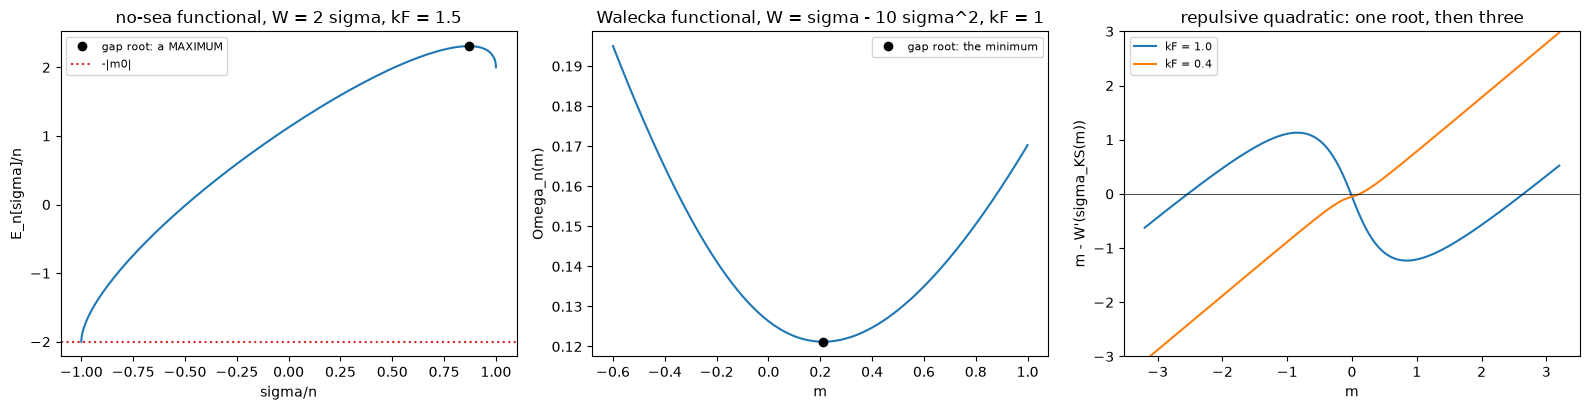

In [3]:
def m_of_sigma(s, kf):
    """The m with sigma_KS(m, kF) = s (odd, increasing, onto (-n, n))."""
    f = lambda m: fermi_sea(m, kf)['sigma'] - s
    hi, lo = kf, -kf
    while f(hi) < 0:
        hi *= 2
    while f(lo) > 0:
        lo *= 2
    return brentq(f, lo, hi, xtol=1e-300, rtol=1e-15, maxiter=500)


def E_nosea(pot, s, kf):
    m = m_of_sigma(s, kf)
    return fermi_sea(m, kf)['eps'] - m * s + pot.W(s)


# (i) the minimax of the no-sea functional, W = 2 sigma, kF = 1.5
Wm, kfm = Pot('mass', m0=2.0), 1.5
n_m = G_FABLE * kfm ** 3 / (6 * PI2)
s_star = fermi_sea(2.0, kfm)['sigma']
E_star = E_nosea(Wm, s_star, kfm)
fr = np.concatenate([-1 + np.geomspace(1e-7, 1e-2, 20), np.linspace(-0.99, 0.99, 149), 1 - np.geomspace(1e-2, 1e-7, 20)])
E_curve = np.array([E_nosea(Wm, f_ * n_m, kfm) for f_ in fr])
h = 1e-3 * n_m
d2T = (E_nosea(Wm, s_star + h, kfm) - 2 * E_star + E_nosea(Wm, s_star - h, kfm)) / h ** 2
chi_star = fermi_sea(2.0, kfm)['chi']
print(f'(i) W = 2 sigma, kF = {kfm}: gap root sigma*/n = {s_star / n_m:.6f}; E_n(sigma*) = {E_star:.12f} = rho = eps_KS(m0) = {fermi_sea(2.0, kfm)["eps"]:.12f}')
print(f'    d2E_n/dsigma2 at the root = {d2T:.6f}, -1/chi = {-1 / chi_star:.6f}: a MAXIMUM;  E_n/n at sigma = -(1 - 1e-7) n = {E_curve[0] / n_m:+.6f} (-> -|m0| = -2)')
assert abs(E_star / fermi_sea(2.0, kfm)['eps'] - 1) < 1e-12 and d2T < 0 and abs(d2T * chi_star + 1) < 1e-3 and E_curve.max() <= E_star + 1e-12

# (ii) the convex Walecka functional, W = sigma - 10 sigma^2, kF = 1
Wa, kfa = Pot('quadratic', v0=0.0, m0=1.0, lam=-20.0), 1.0
ra = gap_roots(Wa, kfa)
ga = mean_field(Wa, ra[0], kfa)
Om = lambda m: fermi_sea(m, kfa)['eps'] + Wa.W((m - 1.0) / -20.0) - m * (m - 1.0) / -20.0
mg = np.linspace(-0.6, 1.0, 161)
Om_curve = np.array([Om(m) for m in mg])
print(f'(ii) W = sigma - 10 sigma^2, kF = 1: {len(ra)} gap root m* = {ra[0]:.10f}, rho = {ga["rho"]:.10f} = Omega(m*) = {Om(ra[0]):.10f};'
      f' Omega convex on the grid: {bool(np.all(np.diff(Om_curve, 2) > 0))}, minimum {Om_curve.min():.10f} at m = {mg[Om_curve.argmin()]:.3f}')
assert len(ra) == 1 and abs(Om(ra[0]) / ga['rho'] - 1) < 1e-12 and np.all(np.diff(Om_curve, 2) > 0) and Om_curve.min() >= Om(ra[0]) - 1e-14

# (iii) uniqueness criterion and the three roots of the repulsive quadratic, with fable_fermion gap
Wr = Pot('quadratic', v0=0.0, m0=0.05, lam=20.0)
kf_c = math.sqrt(4 * PI2 / (20.0 * G_FABLE))
print(f'(iii) W = 0.05 sigma + 10 sigma^2: lam chi0 = 1 at kF = {kf_c:.6f}')
rows3 = []
for kf in (0.4, 1.0):
    roots = gap_roots(Wr, kf)
    mfs = [mean_field(Wr, m, kf) for m in roots]
    best = min(mfs, key=lambda d: d['rho'])
    r = subprocess.run([str(BIN), 'gap', '--form', 'quadratic', '--param', 'm0=0.05', '--param', 'lam=20', '--kf', repr(kf)], check=True, capture_output=True, text=True)
    rust = [list(map(float, l.split(','))) for l in r.stdout.splitlines() if l and not l.startswith('#') and not l.startswith('m,')]
    sel = float(re.search(r'm = ([-+0-9.e]+)', [l for l in r.stdout.splitlines() if l.startswith('# selected')][0]).group(1))
    assert len(rust) == len(roots) and all(abs(d['m'] - rr[0]) <= 1e-10 * max(1.0, abs(rr[0])) for d, rr in zip(mfs, rust)) and abs(sel - best['m']) <= 1e-10
    print(f'    kF = {kf}: lam chi0 = {20 * G_FABLE * kf * kf / (4 * PI2):.4f}, {len(roots)} root(s) (Python and fable_fermion gap agree):')
    for d in mfs:
        tag = '  <- lowest rho: the ground state' if d is best else ''
        print(f'        m = {d["m"]:+.10f}   rho = {d["rho"]:.10f}   (rho + P_obs)/(wF n) = {(d["rho"] + d["P_obs"]) / (d["wF"] * d["n8"]):.12f}{tag}')
        rows3.append(('repulsive quadratic roots', kf, d['m'], d['rho']))
assert len(gap_roots(Wr, 0.4)) == 1 and len(gap_roots(Wr, 1.0)) == 3

rows = [('no-sea E_n(sigma)/n, W = 2 sigma, kF = 1.5; x = sigma/n', float(a_), float(b_ / n_m)) for a_, b_ in zip(fr, E_curve)]
rows += [('Walecka Omega(m), W = sigma - 10 sigma^2, kF = 1; x = m', float(a_), float(b_)) for a_, b_ in zip(mg, Om_curve)]
rows += [(lab, float(kf), float(m), float(rho)) for lab, kf, m, rho in rows3]
write_table('nb07_homogeneous.csv', ['curve', 'x_or_kF', 'value_or_m', 'rho'], [list(r) + ([''] if len(r) == 3 else []) for r in rows])
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].plot(fr, E_curve / n_m); ax[0].plot(s_star / n_m, E_star / n_m, 'ko', label='gap root: a MAXIMUM'); ax[0].axhline(-2.0, color='tab:red', ls=':', label='-|m0|')
ax[0].set_xlabel('sigma/n'); ax[0].set_ylabel('E_n[sigma]/n'); ax[0].set_title('no-sea functional, W = 2 sigma, kF = 1.5'); ax[0].legend(fontsize=8)
ax[1].plot(mg, Om_curve); ax[1].plot(ra[0], Om(ra[0]), 'ko', label='gap root: the minimum'); ax[1].set_xlabel('m'); ax[1].set_ylabel('Omega_n(m)')
ax[1].set_title('Walecka functional, W = sigma - 10 sigma^2, kF = 1'); ax[1].legend(fontsize=8)
mm_ = np.linspace(-3.2, 3.2, 801)
for kf, col in ((1.0, 'tab:blue'), (0.4, 'tab:orange')):
    ax[2].plot(mm_, [gap_function(Wr, m, kf) for m in mm_], color=col, label=f'kF = {kf}')
ax[2].axhline(0, color='k', lw=0.5); ax[2].set_ylim(-3, 3); ax[2].set_xlabel('m'); ax[2].set_ylabel("m - W'(sigma_KS(m))")
ax[2].set_title('repulsive quadratic: one root, then three'); ax[2].legend(fontsize=8)
fig.tight_layout(); fig.savefig(RESULTS / 'nb07_homogeneous.png', dpi=130, bbox_inches='tight'); print('figure: results/nb07_homogeneous.png'); plt.show()

### 5.2 The first excited states of the homogeneous gas: gapless particle–hole pairs, and the pair continuum

In the ground state the positive-energy states `|k| < kF` are filled and the Dirac sea is full.  A
**particle–hole** excitation of total momentum `Q` moves a fermion from `k` (`|k| < kF`) to `k + Q`
(`|k + Q| > kF`) at the cost `ω(k + Q) − ω(k)`.  Its minimum over `k` vanishes for every `Q ≤ 2kF`
(Fermi surface to Fermi surface): the excitations are gapless, and in the thermodynamic limit the
lowest of them is degenerate with the ground state.  A **pair** excitation creates a particle at `p`
(`|p| ≥ kF`, Pauli) and a hole in the Dirac sea (an antiparticle of energy `ω(p′)`), total momentum
`Q = p − p′`.  Its threshold is `wF + ω(|kF − Q|)` for `Q ≤ 2kF` (the particle on the Fermi surface) and
`2ω(Q/2)` beyond: `2wF` at `Q = 0`, and its lowest point is `wF + |m|` at `Q = kF`.  The cell minimizes both energies by brute force over the
momenta (a grid of `p` in the plane of `Q`, at `m = 1`, `kF = 1.5`), compares them with these closed
forms, and writes `results/nb07_excitations.csv` and `results/nb07_excitations.png`.

m = 1.0, kF = 1.5, wF = 1.802776:  largest |brute force - closed form|: particle-hole 1.31e-03, pair 4.44e-16 (grid-limited)
particle-hole threshold = 0 for Q <= 2 kF = 3.0: gapless;  pair threshold at Q = 0: 3.605551 (2 wF = 3.605551);  lowest pair threshold 2.802776 at Q = 1.50 (wF + |m| = 2.802776 at Q = kF)
written: results/nb07_excitations.csv
figure: results/nb07_excitations.png


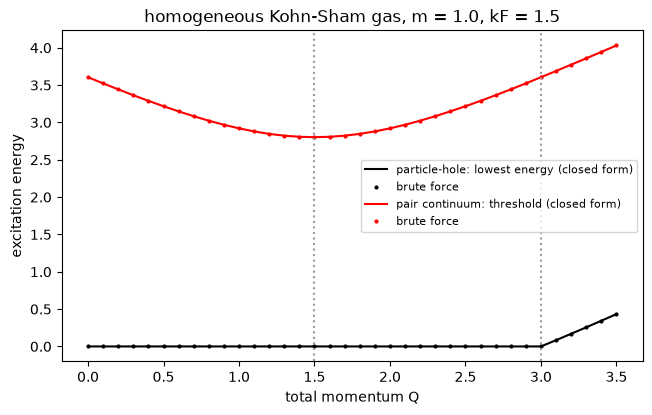

In [4]:
m_e, kf_e = 1.0, 1.5
om = lambda k: np.sqrt(k * k + m_e * m_e)
wF_e = om(kf_e)
Qs = np.linspace(0.0, 3.5, 36)
th_ = np.linspace(0.0, np.pi, 2881)
rows, dev_ph, dev_pair = [], 0.0, 0.0
for Q in Qs:
    # particle-hole: k inside the Fermi ball, k + Q outside; minimize omega(k + Q) - omega(k) on a polar grid
    kk = np.linspace(0.0, kf_e, 301)[:, None]
    kx, ky = kk * np.cos(th_), kk * np.sin(th_)
    kq = np.hypot(kx + Q, ky)
    dE = np.where(kq >= kf_e, om(kq) - om(kk), np.inf)
    ph = float(dE.min())
    ph_exact = 0.0 if Q <= 2 * kf_e else float(om(Q - kf_e) - wF_e)
    # pair: particle at p (|p| >= kF), antiparticle from the sea at p' = p - Q; minimize omega(p) + omega(p - Q)
    pp = np.linspace(kf_e, kf_e + 4.0, 801)[:, None]
    px, py = pp * np.cos(th_), pp * np.sin(th_)
    pair = float((om(pp) + om(np.hypot(px - Q, py))).min())
    pair_exact = float(wF_e + om(abs(kf_e - Q))) if Q <= 2 * kf_e else float(2 * om(Q / 2))
    dev_ph, dev_pair = max(dev_ph, abs(ph - ph_exact)), max(dev_pair, abs(pair - pair_exact))
    rows.append([float(Q), ph, ph_exact, pair, pair_exact])
rows_a = np.array(rows)
i_min = int(np.argmin(rows_a[:, 4]))
print(f'm = {m_e}, kF = {kf_e}, wF = {wF_e:.6f}:  largest |brute force - closed form|: particle-hole {dev_ph:.2e}, pair {dev_pair:.2e} (grid-limited)')
print(f'particle-hole threshold = 0 for Q <= 2 kF = {2 * kf_e}: gapless;  pair threshold at Q = 0: {rows_a[0, 3]:.6f} (2 wF = {2 * wF_e:.6f});'
      f'  lowest pair threshold {rows_a[i_min, 4]:.6f} at Q = {rows_a[i_min, 0]:.2f} (wF + |m| = {wF_e + m_e:.6f} at Q = kF)')
assert dev_ph < 2e-2 and dev_pair < 1e-9 and abs(rows_a[0, 1]) < 1e-12 and abs(rows_a[i_min, 0] - kf_e) < 0.051
write_table('nb07_excitations.csv', ['Q', 'particle_hole_min_bruteforce', 'particle_hole_min_closed', 'pair_min_bruteforce', 'pair_min_closed'], rows)
fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.plot(rows_a[:, 0], rows_a[:, 2], 'k-', label='particle-hole: lowest energy (closed form)'); ax.plot(rows_a[:, 0], rows_a[:, 1], 'k.', ms=4, label='brute force')
ax.plot(rows_a[:, 0], rows_a[:, 4], 'r-', label='pair continuum: threshold (closed form)'); ax.plot(rows_a[:, 0], rows_a[:, 3], 'r.', ms=4, label='brute force')
ax.axvline(kf_e, color='0.6', ls=':'); ax.axvline(2 * kf_e, color='0.6', ls=':')
ax.set_xlabel('total momentum Q'); ax.set_ylabel('excitation energy'); ax.set_title(f'homogeneous Kohn-Sham gas, m = {m_e}, kF = {kf_e}'); ax.legend(fontsize=8)
fig.savefig(RESULTS / 'nb07_excitations.png', dpi=130, bbox_inches='tight'); print('figure: results/nb07_excitations.png'); plt.show()

### 5.3 The wall problem: the derivation (quoted from its log) and the solver's validation

`fermion/waveguide_derivation.wls` loads the Input cells 1–117 of the Mathematica notebook and derives
the wall problem from the notebook's own `T16`, `gammaCurvedCanonical`, `GammaSpinCanonical` and
`cfDcov16`.  The first cell reads its committed log `fermion/waveguide_derivation.log`, prints its key
PASS lines (the rescaling, the proper distance, the 2×2 blocks, the wall conditions, the symmetries,
the endpoints and the spectrum structure) and checks that every one of its checks passed.  The second
builds `T16` here exactly as the notebook does, compares it with the matrices the derivation exported
to the committed file `fermion/waveguide_T16.json`, and runs `python waveguide.py validate`: exact solutions (constant
`K`, the flat band `ω = m` for `g(0) = 0`), the Hellmann–Feynman theorem, Magnus against DOP853, the
16-component multiplicities with the notebook's `T16`, the block basis, and the closed-form slope of
the edge band.  It asserts that all 64 checks pass.

In [5]:
log = (FERMION / 'waveguide_derivation.log').read_text(encoding='utf-8')
lines = log.splitlines()
n_pass = sum(1 for l in lines if l.strip().startswith('PASS'))
n_fail = sum(1 for l in lines if l.strip().startswith('FAIL'))
m_sum = re.search(r'(\d+) checks, (\d+) PASS, (\d+) FAIL', log)
print('\n'.join(l.strip() for l in lines[1:4]))
keys = ['RESCALING', 'the wall is at FINITE proper distance', 'transverse term', 'the one-particle space of Psi', 'curvature singularity at finite proper distance',
        'dim <alz, alx, bet, J> = 16', 'every joint eigenspace', 'irrep w3 = -i (4 blocks)', 'irrep w3 = +i (4 blocks)',
        'MIT T16[0] Psi = eps Psi', 'maximal isotropic', 'MIT+ (T0 Psi = +Psi, 8-dim)', 'only the two MIT conditions are covariant',
        'flavour symmetry (Q central) AND C select', 'S(K) = S(-K) = -S(K)', 'REGULAR endpoint', 'limit point', 'a flat band', 'NO bound state']
quoted = []
for k in keys:
    hit = next((l.strip() for l in lines if k in l and l.strip().startswith('PASS')), None)
    assert hit is not None, f'no PASS line containing {k!r} in the derivation log'
    quoted.append(hit)
    print('  ' + (hit if len(hit) <= 230 else hit[:227] + '...'))
i_c = next(i for i, l in enumerate(lines) if 'CONSEQUENCE (MIT walls)' in l)
print('\n'.join('  ' + l.strip() for l in lines[i_c:i_c + 4]))
print(f'derivation log: {n_pass} PASS lines, {n_fail} FAIL lines; summary line: "{m_sum.group(0)}"')
assert n_fail == 0 and int(m_sum.group(1)) == int(m_sum.group(2)) == n_pass and int(m_sum.group(3)) == 0

waveguide_derivation.wls   2026-09-25 00:06:38
Mathematica 15.0.1 for Microsoft Windows (64-bit) (July 2, 2026)
notebook: C:\Users\nsh\Documents\8-dim\Pre-Universe_14SEP26-77\claude-fable\claude-fable_Einstein-Rosen-2-Planes.nb
  PASS  RESCALING: with Psi = Sqrt[Sin[6Hx0]] Psi' the connection term is removed EXACTLY: (gamma.D - m) Psi = Sqrt[Sin] e^{..} [Cot T0 d0 + i k e^{A4} Sin^(1/6) T1 - i om T4 - m] Psi'
  PASS  z(x0) -> 0 as x0 -> 0 (the wall is at FINITE proper distance) and z -> Infinity as 6Hx0 -> Pi/2
  PASS  transverse term: k e^{A4} Sin[6Hx0]^(1/6) == K(z) = K_inf (1 - e^{-12 H z})^(1/12) with K_inf = k e^{A4}
  PASS  hence Sqrt|g| |Psi|^2 dx0 = |Psi'|^2 dz: the one-particle space of Psi' is L^2(dz) (per unit transverse coordinate volume)
  PASS  the wall is a curvature singularity at finite proper distance: R z^2 -> -31/24 as z -> 0 (R ~ 1/z^2)
  PASS  dim <alz, alx, bet, J> = 16 = 4 x dim M2(C): A = M2 (+) M2 (+) M2 (+) M2, one M2 per character (w3, J) = (+-i, +-1)
  PASS

`T16` built here against the exported matrices, then the validation of the wall-state solver (about half
a minute).  The validation reads the committed file `fermion/waveguide_T16.json`; if it has been
removed, the cell says how to rewrite it from the Mathematica notebook and stops.

In [6]:
T16, S16 = build_T16()
assert all(np.array_equal(T16[a] @ T16[b] + T16[b] @ T16[a], 2 * ((1 if a < 4 else -1) if a == b else 0) * np.eye(16)) for a in range(8) for b in range(8))
jpath = FERMION / 'waveguide_T16.json'
if not jpath.exists():
    print(f'{jpath} is missing (it is part of the repository).  It is rewritten by  wolframscript -file fable-cosmology/fermion/waveguide_derivation.wls  (about 3.5 minutes; needs Mathematica).')
    raise SystemExit(1)
jd = json.loads(jpath.read_text())
same = [bool(np.array_equal(np.array(jd['T16'][a], float), T16[a])) for a in range(9)] + [bool(np.array_equal(np.array(jd['sigma16'], float), S16))]
print(f'T16[0..8] and sigma16 built here are identical to the matrices exported by the derivation: {all(same)} ({sum(same)} of {len(same)})')
assert all(same)
out = run_wg('validate')
mv = re.search(r'VALIDATION: (\d+) of (\d+) PASS', out)
N_VALID = (int(mv.group(1)), int(mv.group(2)))
print(f'validation: {N_VALID[0]} of {N_VALID[1]} PASS')
assert N_VALID == (64, 64)

T16[0..8] and sigma16 built here are identical to the matrices exported by the derivation: True (10 of 10)
$ python fermion/waveguide.py validate


waveguide.py validate   (python 3.14.5, numpy 2.5.3)
  PASS  V1 constant K=0.3, MIT- (f=-g): single level w = -K   [w = -0.299999999999999, err = 6.11e-16]
  PASS  V1 constant K=3.0, MIT- (f=-g): single level w = -K   [w = -3, err = 0.00e+00]
  PASS  V1 constant K=20.0, MIT- (f=-g): single level w = -K   [w = -20, err = 0.00e+00]
  PASS  V1 constant K=80.0, MIT- (f=-g): single level w = -K   [w = -80, err = 0.00e+00]
  PASS  V2 constant K=0.7, th=-1.30: closed form   [w = 1.21773971364 vs exact 1.21773971364]
  PASS  V2 constant K=0.7, th=-0.90: closed form   [none expected (kappa_exact = -0.815); found []]
  PASS  V2 constant K=0.7, th=-0.40: closed form   [none expected (kappa_exact = -1.21); found []]
  PASS  V2 constant K=0.7, th=+0.20: closed form   [none expected (kappa_exact = -0.255); found []]
  PASS  V2 constant K=0.7, th=+0.60: closed form   [w = -1.01478511465 vs exact -1.01478511465]
  PASS  V2 constant K=0.7, th=+1.00: closed form   [w = -0.220361362231 vs exact -0.220361

### 5.4 The wall conditions `P Ψ(0) = Ψ(0)`, `P = T16[0] Q`, and why the MIT walls

With the `T16` built above the cell checks, for `Q = +1, −1, +J, −J`: `P` is a Hermitian involution,
commutes with `J`, and commutes with the six generators `T16[a]T16[b]` of the wall's `Spin(1,3)` of
`x1, x2, x3, x4` (covariance).  On its 8-dimensional `+1` eigenspace (basis `V`) the scalar density and
the normal current vanish for every complex `Ψ`: the matrices `V^† σ16 V` and `V^† σ16 T16[0] V` are zero.
Whether `P` is real decides invariance under the charge conjugation `Ψ → Ψ^*` (`T16` is real, `J^* = −J`):
only `Q = ±1` pass, the MIT walls `T16[0]Ψ = ±Ψ`.  For contrast, the non-covariant member
`β = −iT16[4]` of the uniform family `cos φ β + sin φ T16[0]` anticommutes with the boosts `T16[i]T16[4]`.
The table goes to `results/nb07_wall_conditions.csv`.

In [7]:
T0 = T16[0]
J = -1j * (T16[0] @ T16[1] @ T16[2] @ T16[3] @ T16[4])
bet = -1j * T16[4]
I16 = np.eye(16)
gens = [(a, b) for a, b in itertools.combinations((1, 2, 3, 4), 2)]
rows = []
print(f"{'Q':>3s} {'Hermitian':>9s} {'P^2 = 1':>7s} {'[P,J]=0':>7s} {'covariant':>9s} {'|V+ s16 V|':>10s} {'|V+ s16 T0 V|':>13s} {'P real (C)':>10s}")
for lab, Q in (('+1', I16), ('-1', -I16), ('+J', J), ('-J', -J)):
    P = T0 @ Q
    ev, V = np.linalg.eigh(P)
    Vp = V[:, ev > 0]
    herm, inv, commJ = np.allclose(P, P.conj().T), np.allclose(P @ P, I16), np.allclose(P @ J, J @ P)
    cov = all(np.allclose(P @ (T16[a] @ T16[b]), (T16[a] @ T16[b]) @ P) for a, b in gens)
    sc, cur = np.abs(Vp.conj().T @ S16 @ Vp).max(), np.abs(Vp.conj().T @ (S16 @ T0) @ Vp).max()
    real = bool(np.allclose(P.imag, 0))
    rows.append([lab, herm, inv, commJ, cov, int(Vp.shape[1]), float(sc), float(cur), real])
    print(f'{lab:>3s} {str(herm):>9s} {str(inv):>7s} {str(commJ):>7s} {str(cov):>9s} {sc:10.1e} {cur:13.1e} {str(real):>10s}')
    assert herm and inv and commJ and cov and Vp.shape[1] == 8 and sc < 1e-12 and cur < 1e-12
assert [r[-1] for r in rows] == [True, True, False, False]
anti_boost = all(np.allclose(bet @ (T16[i] @ T16[4]), -(T16[i] @ T16[4]) @ bet) for i in (1, 2, 3))
comm_rot = all(np.allclose(bet @ (T16[i] @ T16[j]), (T16[i] @ T16[j]) @ bet) for i, j in ((1, 2), (1, 3), (2, 3)))
print(f'beta = -i T16[4] anticommutes with the three boosts T16[i]T16[4]: {anti_boost}; commutes with the rotations T16[i]T16[j]: {comm_rot}'
      ' -> only cos(phi) = 0 in cos(phi) beta + sin(phi) T16[0] is covariant: the MIT walls')
assert anti_boost and comm_rot
write_table('nb07_wall_conditions.csv', ['Q', 'hermitian', 'involution', 'commutes_with_J', 'covariant_Spin13', 'dim_plus_space',
                                         'max_scalar_density_form', 'max_normal_current_form', 'real_C_invariant'], rows)

  Q Hermitian P^2 = 1 [P,J]=0 covariant |V+ s16 V| |V+ s16 T0 V| P real (C)
 +1      True    True    True      True    2.2e-17       2.2e-17       True
 -1      True    True    True      True    2.2e-17       2.2e-17       True
 +J      True    True    True      True    2.2e-17       2.2e-17      False
 -J      True    True    True      True    2.2e-17       2.2e-17      False
beta = -i T16[4] anticommutes with the three boosts T16[i]T16[4]: True; commutes with the rotations T16[i]T16[j]: True -> only cos(phi) = 0 in cos(phi) beta + sin(phi) T16[0] is covariant: the MIT walls
written: results/nb07_wall_conditions.csv


### 5.5 The structure of the spectrum: `S(K) = A(K) ∪ (−A(K))`, every level 4-fold

With MIT walls the levels of the irrep `w3 = +i` are the negatives of those of `w3 = −i`, so the
16-component spectrum at transverse momentum `K` is `A(K) ∪ (−A(K))`, `A(K)` the levels of the `s = +1`
block equation, and every positive level is 4-fold per transverse momentum vector (two blocks with
`J = +1`, two with `J = −1`, of one irrep).  The cell computes both irreps at `K = 80` (same-sign wall,
`m = H = 1`) with `waveguide.find_levels`, checks the symmetry, and then counts the multiplicity of
levels directly in the **16-component** problem with the `T16` built in this notebook: the number of
vanishing singular values of the matched left and right solution spaces
(`waveguide.full16_singular_values`).  The positive levels go to `results/nb07_levels_K80.csv`.

In [8]:
K80 = 80.0
Aminus, c1 = wg.find_levels(wg.Block(Kinf=K80, m=1.0, theta=wg.theta_MIT(+1)))
Aplus, c2 = wg.find_levels(wg.Block(Kinf=-K80, m=1.0, theta=wg.theta_MIT(+1)))
print(f'K = {K80}, same-sign MIT wall, m = H = 1, continuum from R = {math.hypot(1.0, K80):.9f}')
print('  irrep -i (s = +1): ' + ', '.join(f'{L.w:+.9f}' for L in Aminus) + f'   (exact count {c1})')
print('  irrep +i (s = -1): ' + ', '.join(f'{L.w:+.9f}' for L in Aplus) + f'   (exact count {c2})')
sym = max(abs(a + b) for a, b in zip(sorted(L.w for L in Aminus), sorted((L.w for L in Aplus), reverse=True)))
print(f'max |A_(+i) + A_(-i)| (the om -> -om symmetry) = {sym:.1e}')
assert c1 == len(Aminus) and c2 == len(Aplus) and len(Aminus) == len(Aplus) and sym < 1e-9
LEV80 = sorted([(L.w, '-i', L.kappa) for L in Aminus if L.w > 0] + [(L.w, '+i', L.kappa) for L in Aplus if L.w > 0])
rows = []
for n, (w, irr, kap) in enumerate(LEV80):
    sv, zm = wg.full16_singular_values(w, K80, 1.0, +1, T16)
    mult = int(np.sum(sv < 1e-6))
    rows.append([n, w, irr, kap, math.hypot(1.0, K80) - w, mult])
    print(f'  n = {n}: omega = {w:.9f} (irrep {irr}), kappa = {kap:.4f}, binding R - omega = {math.hypot(1.0, K80) - w:.6f};'
          f' 16-component multiplicity {mult} (smallest singular values {sv[-1]:.1e}, next {sv[-mult - 1]:.2f})')
    assert mult == 4
for w in (-LEV80[0][0], 0.37 * math.hypot(1.0, K80)):
    sv, _ = wg.full16_singular_values(w, K80, 1.0, +1, T16)
    print(f'  omega = {w:+.6f}: 16-component multiplicity {int(np.sum(sv < 1e-6))}' + ('  (the mirror level: 4-fold as well)' if w < 0 else '  (not a level)'))
    assert int(np.sum(sv < 1e-6)) == (4 if w < 0 else 0)
write_table('nb07_levels_K80.csv', ['n', 'omega', 'irrep', 'kappa', 'binding_R_minus_omega', 'multiplicity_16'], rows)

K = 80.0, same-sign MIT wall, m = H = 1, continuum from R = 80.006249756
  irrep -i (s = +1): -79.987308552, -78.144249332, +70.985307230, +79.371495779   (exact count 4)
  irrep +i (s = -1): -79.371495779, -70.985307230, +78.144249332, +79.987308552   (exact count 4)
max |A_(+i) + A_(-i)| (the om -> -om symmetry) = 1.3e-11


  n = 0: omega = 70.985307230 (irrep -i), kappa = 36.9065, binding R - omega = 9.020943; 16-component multiplicity 4 (smallest singular values 6.5e-08, next 0.46)


  n = 1: omega = 78.144249332 (irrep +i), kappa = 17.1603, binding R - omega = 1.862000; 16-component multiplicity 4 (smallest singular values 8.4e-10, next 0.18)


  n = 2: omega = 79.371495779 (irrep -i), kappa = 10.0581, binding R - omega = 0.634754; 16-component multiplicity 4 (smallest singular values 1.5e-11, next 0.20)
  n = 3: omega = 79.987308552 (irrep +i), kappa = 1.7408, binding R - omega = 0.018941; 16-component multiplicity 4 (smallest singular values 3.5e-10, next 0.10)


  omega = -70.985307: 16-component multiplicity 4  (the mirror level: 4-fold as well)


  omega = +29.602312: 16-component multiplicity 0  (not a level)
written: results/nb07_levels_K80.csv


### 5.6 The thresholds `K_c(1)`, `K_c(2)` of the same-sign wall versus `m/H`

A same-sign wall binds nothing at small transverse momentum: a level appears only where the pocket
`K(z)` near the wall is deep enough.  `python waveguide.py threshold` finds, for `m/H = 0.25 … 8`, the
transverse momentum at which the first and the second positive level of the 16-component problem
appear (exact Prüfer count, bisection to `1e−9`), the irrep in which each appears, the second level
within irrep `−i` alone, and the thresholds of the opposite-sign wall.  The cell prints its output,
copies its table to `results/nb07_thresholds.csv` and draws `results/nb07_thresholds.png`.

$ python fermion/waveguide.py threshold


waveguide.py threshold   (python 3.14.5, numpy 2.5.3)

THRESHOLDS of the same-sign MIT wall (T0 Psi = sign(m) Psi), H = 1: K_inf at which the n-th POSITIVE level
of the full 16-component problem appears (exact Pruefer count, bisection to 1e-9 relative)
   m/H |       K_c(1)/H irrep   K_c(1)/m |       K_c(2)/H irrep   K_c(2)/m
  0.25 |     3.39259952    -i   13.57040 |    33.87815035    +i  135.51260
  0.50 |     4.77916520    -i    9.55833 |    33.89177761    +i   67.78356
  1.00 |     6.70624065    -i    6.70624 |    33.91895851    +i   33.91896
  2.00 |     9.33759991    -i    4.66880 |    33.97299731    +i   16.98650
  4.00 |    12.80358979    -i    3.20090 |    34.07956537    +i    8.51989
  8.00 |    17.04604924    -i    2.13076 |    34.28513351    +i    4.28564

  second positive level WITHIN irrep -i (same-sign, m = H) appears at K = 49.540216755
  pocket width: K(z)^2/K_inf^2 = (1 - e^(-12Hz))^(1/6) = 0.875776 (z = 0.05/H), 0.942018 (z = 0.1/H), 0.984275 (z = 0.2/H)
  opposite-

figure: results/nb07_thresholds.png


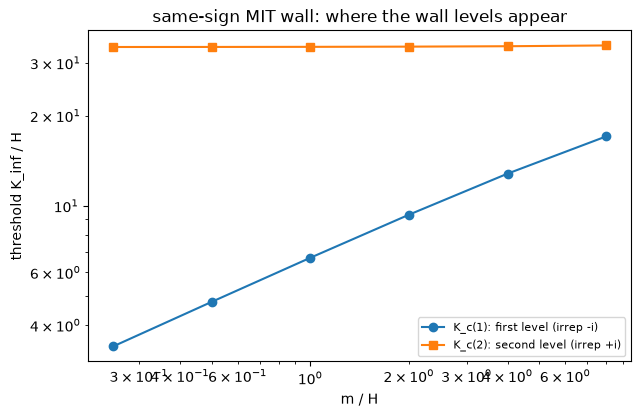

In [9]:
out_thr = run_wg('threshold')
thr = dev_rows('waveguide_thresholds.csv')
THR = {r['m_over_H']: r for r in thr}
write_table('nb07_thresholds.csv', ['m_over_H', 'Kc1_over_H', 'irrep1', 'Kc2_over_H', 'irrep2'],
            [[r['m_over_H'], r['Kc1_over_H'], r['irrep1'], r['Kc2_over_H'], r['irrep2']] for r in thr])
assert all(r['irrep1'] == '-i' and r['irrep2'] == '+i' for r in thr)
K_WITHIN = float(re.search(r'WITHIN irrep -i .*? at K = ([\d.]+)', out_thr).group(1))
K_OPP = [float(x) for x in re.findall(r'K = ([\d.]+) \(irrep', out_thr.split('opposite-sign wall')[1])]
ms_ = np.array([r['m_over_H'] for r in thr]); k1 = np.array([r['Kc1_over_H'] for r in thr]); k2 = np.array([r['Kc2_over_H'] for r in thr])
slope1 = np.polyfit(np.log(ms_), np.log(k1), 1)[0]
print(f'K_c(1) grows like (m/H)^{slope1:.3f} over m/H = {ms_[0]:g}..{ms_[-1]:g}; K_c(2) ranges only over {k2.min():.4f}..{k2.max():.4f} H')
print(f'second level within irrep -i (m = H): K = {K_WITHIN:.9f};  opposite-sign wall, further levels at K = {", ".join(f"{k:.8f}" for k in K_OPP)}')
fig, ax = plt.subplots(figsize=(7, 4.3))
ax.loglog(ms_, k1, 'o-', label='K_c(1): first level (irrep -i)'); ax.loglog(ms_, k2, 's-', label='K_c(2): second level (irrep +i)')
ax.set_xlabel('m / H'); ax.set_ylabel('threshold K_inf / H'); ax.set_title('same-sign MIT wall: where the wall levels appear'); ax.legend(fontsize=8)
fig.savefig(RESULTS / 'nb07_thresholds.png', dpi=130, bbox_inches='tight'); print('figure: results/nb07_thresholds.png'); plt.show()

### 5.7 The dispersion `ω_n(K)`, n = 0…3, of the same-sign wall, and the levels at `K = 80`

`python waveguide.py figures` computes the positive levels of the 16-component problem for
`K = 7, 8, …, 100` (same-sign and opposite-sign walls), the edge band, the `θ` family and the
wavefunctions.  The cell prints its output, draws `ω_n(K)` and the binding `R − ω_n` (the depth below the
continuum), checks its `K = 80` row against the levels of 5.5, and compares those with the independent
Mathematica values (`NDSolve` at 30 digits, `fermion/waveguide_check.wls`) that the solver's committed
report `fermion/waveguide_REPORT.txt` lists.  The table goes to `results/nb07_dispersion_same.csv`, the
figure to `results/nb07_dispersion.png`.

$ python fermion/waveguide.py figures


  (24.6 s)
DISPERSION omega_n(K), same-sign (MIT+) wall, m/H = 1.0, H = 1:
positive levels of the 16-component problem, n = 0, 1, 2, ... in increasing omega
(each 4-fold per transverse momentum vector; irrep -i = block ODE with +K, irrep +i = with -K)
     K  R=sqrt(m2+K2) | omega_n (irrep) [R - omega_n]
   7.0     7.07106781 | 7.07061457(-i)[0.000453]
   8.0     8.06225775 | 8.05383823(-i)[0.00842]
  10.0    10.04987562 | 9.99920505(-i)[0.0507]
  15.0    15.03329638 | 14.75649923(-i)[0.277]
  20.0    20.02498439 | 19.39490065(-i)[0.63]
  30.0    30.01666204 | 28.42191687(-i)[1.59]
  35.0    35.01428280 | 32.84214128(-i)[2.17]  35.01273142(+i)[0.00155]
  40.0    40.01249805 | 37.21339774(-i)[2.8]  39.96656027(+i)[0.0459]
  45.0    45.01110974 | 41.54234204(-i)[3.47]  44.86721755(+i)[0.144]
  50.0    50.00999900 | 45.83408535(-i)[4.18]  49.72238768(+i)[0.288]  50.00982259(-i)[0.000176]
  60.0    60.00833275 | 54.32136437(-i)[5.69]  59.31765921(+i)[0.691]  59.92357565(-i)[0.0848]
  70.0 

figure: results/nb07_dispersion.png


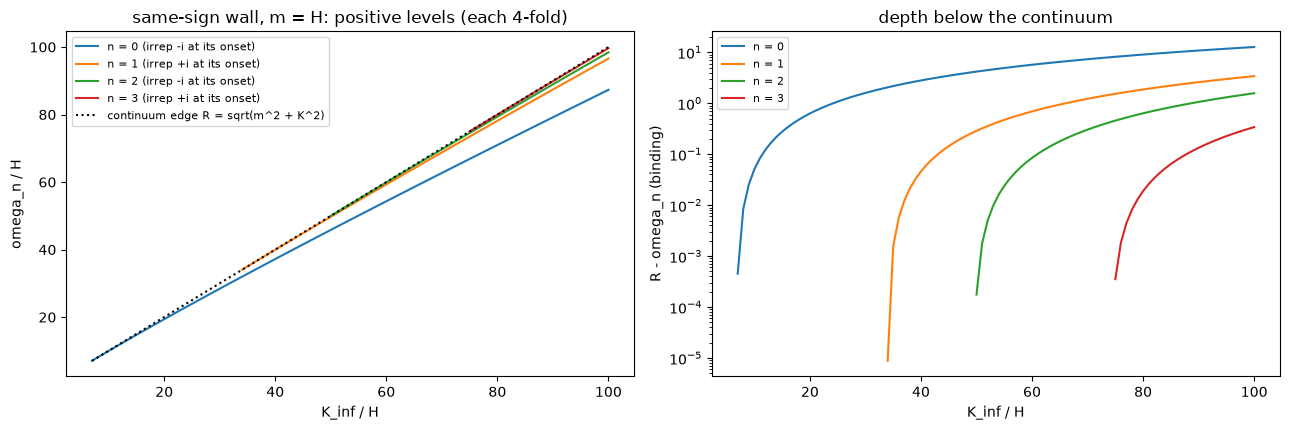

In [10]:
out_fig = run_wg('figures', show=False)
print('DISPERSION' + out_fig.split('DISPERSION')[1].split(2 * chr(10))[0])
disp = dev_rows('waveguide_dispersion_same_m1.csv')
write_table('nb07_dispersion_same.csv', ['K', 'R_continuum', 'n', 'omega', 'irrep', 'kappa', 'R_minus_omega'],
            [[r['K'], r['R_continuum'], int(r['n']), r['omega'], r['irrep'], r['kappa'], r['R_minus_omega']] for r in disp])
row80 = sorted([(r['omega'], r['irrep']) for r in disp if r['K'] == 80.0])
d_mod = max(abs(a[0] - b[0]) for a, b in zip(row80, LEV80))
print(f'K = 80 from the table: {", ".join(f"{w:.9f} ({i})" for w, i in row80)};  max |table - 5.5| = {d_mod:.1e}')
assert len(row80) == len(LEV80) == 4 and d_mod < 1e-9 and [i for _, i in row80] == [i for _, i, _ in LEV80]
rep = (FERMION / 'waveguide_REPORT.txt').read_text(encoding='utf-8')
MATH80 = {}
for mt in re.finditer(r'same-sign K=80 n=(\d) \(irrep ([-+]i)\)\s+([-+\d.]+)\s+([-+\d.]+)\s+([\d.e+-]+)', rep):
    MATH80[int(mt.group(1))] = float(mt.group(4))
dmath = max(abs(LEV80[n][0] - MATH80[n]) for n in range(4))
print('Mathematica (waveguide_check.wls, as listed in waveguide_REPORT.txt): ' + ', '.join(f'n = {n}: {MATH80[n]:.11f}' for n in range(4))
      + f';  max |notebook - Mathematica| = {dmath:.1e}')
assert len(MATH80) == 4 and dmath < 1e-9
Ks_ = sorted(set(r['K'] for r in disp))
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
for n, col in zip(range(4), ('tab:blue', 'tab:orange', 'tab:green', 'tab:red')):
    pts = [(r['K'], r['omega'], r['R_minus_omega'], r['irrep']) for r in disp if int(r['n']) == n]
    if pts:
        P_ = np.array([(a, b, c) for a, b, c, _ in pts])
        ax[0].plot(P_[:, 0], P_[:, 1], color=col, label=f'n = {n} (irrep {pts[0][3]} at its onset)')
        ax[1].semilogy(P_[:, 0], P_[:, 2], color=col, label=f'n = {n}')
ax[0].plot(Ks_, [math.hypot(1.0, k) for k in Ks_], 'k:', label='continuum edge R = sqrt(m^2 + K^2)')
ax[0].set_xlabel('K_inf / H'); ax[0].set_ylabel('omega_n / H'); ax[0].set_title('same-sign wall, m = H: positive levels (each 4-fold)'); ax[0].legend(fontsize=8)
ax[1].set_xlabel('K_inf / H'); ax[1].set_ylabel('R - omega_n (binding)'); ax[1].set_title('depth below the continuum'); ax[1].legend(fontsize=8)
fig.tight_layout(); fig.savefig(RESULTS / 'nb07_dispersion.png', dpi=130, bbox_inches='tight'); print('figure: results/nb07_dispersion.png'); plt.show()

### 5.8 The opposite-sign wall: a gapless edge band and its closed-form slope

With the opposite-sign wall `T16[0]Ψ = −sign(m) Ψ` every transverse momentum carries an edge level, 4-fold,
bound by the wall condition itself.  For small `K` it is the constant-`K` edge state
`Sqrt[2m] e^{−mz}(1, −1)/√2` with `ω = −K`, and the Hellmann–Feynman theorem with the true profile `K(z)`
gives the slope

    ω/K_inf → −∫ 2m e^{−2mz} (1 − e^{−12Hz})^{1/12} dz = −(m/6H) B(m/6H, 13/12)       (B the Euler beta function).

The cell checks it at `K = 1e−4` for `m/H = 0.5, 1, 3`, reads the edge band from the `figures` run, finds
the transverse momentum `K*` at which the edge level reaches the bulk mass (below it, the edge fermions
lie inside the bulk gap: massless fermions on the wall), and the largest surface density
`(4/(6π²)) K*³` they can hold there.  Table `results/nb07_edge_band.csv`, figure `results/nb07_edge_band.png`.

m/H = 0.5: omega/K at K = 1e-4: -0.989859093;  -(m/6H) B(m/6H, 13/12) = -0.989859126;  |diff| = 3.3e-08
m/H = 1.0: omega/K at K = 1e-4: -0.980822728;  -(m/6H) B(m/6H, 13/12) = -0.980822733;  |diff| = 4.3e-09


m/H = 3.0: omega/K at K = 1e-4: -0.952353438;  -(m/6H) B(m/6H, 13/12) = -0.952353687;  |diff| = 2.5e-07


edge band |omega|/K: 0.980823 at K = 0.02 ... 0.868505 at K = 100; it reaches the bulk mass m0 = 1 at K* = 1.01971543
below K* the edge fermions are inside the bulk gap: at most N_s = (4/(6 pi^2)) K*^3 = 0.071622 H^3 of them per unit coordinate 3-volume
written: results/nb07_edge_band.csv
figure: results/nb07_edge_band.png


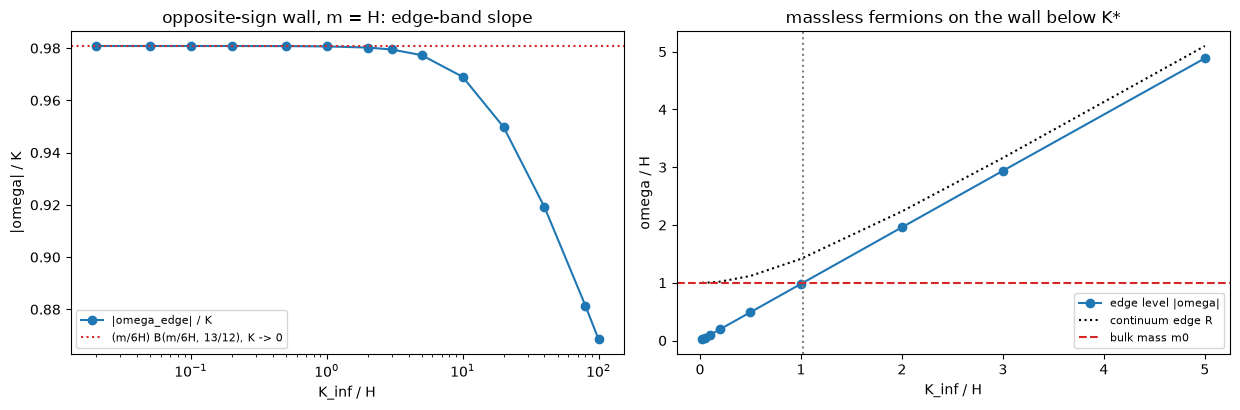

In [11]:
rows_s = []
for mm in (0.5, 1.0, 3.0):
    lv, _ = wg.find_levels(wg.Block(Kinf=1e-4, m=mm, theta=wg.theta_MIT(-1)))
    slope = min(lv, key=lambda X: abs(X.w + 1e-4)).w / 1e-4
    exact = -(mm / 6.0) * Beta(mm / 6.0, 13.0 / 12.0)
    rows_s.append([mm, slope, exact])
    print(f'm/H = {mm}: omega/K at K = 1e-4: {slope:.9f};  -(m/6H) B(m/6H, 13/12) = {exact:.9f};  |diff| = {abs(slope - exact):.1e}')
    assert abs(slope - exact) < 1e-6
SLOPE1 = rows_s[1][2]
edge = dev_rows('waveguide_edge_m1.csv')
EK = sorted(set(r['K'] for r in edge))
ed = []
for K in EK:
    A = [r['omega'] for r in edge if r['K'] == K and r['irrep'] == '-i']
    e_ = max(w for w in A if w < 0)
    ed.append((K, abs(e_), abs(e_) / K, math.hypot(1.0, K)))
ed = np.array(ed)


def edge_level(K):
    lv, _ = wg.find_levels(wg.Block(Kinf=K, m=1.0, theta=wg.theta_MIT(-1)))
    return abs(max(L.w for L in lv if L.w < 0))


K_STAR = brentq(lambda K: edge_level(K) - 1.0, 0.9, 1.2, xtol=1e-10)
NS_MAX = 4.0 / (6 * PI2) * K_STAR ** 3
print(f'edge band |omega|/K: {ed[0, 2]:.6f} at K = {ed[0, 0]:g} ... {ed[-1, 2]:.6f} at K = {ed[-1, 0]:g}; it reaches the bulk mass m0 = 1 at K* = {K_STAR:.8f}')
print(f'below K* the edge fermions are inside the bulk gap: at most N_s = (4/(6 pi^2)) K*^3 = {NS_MAX:.6f} H^3 of them per unit coordinate 3-volume')
write_table('nb07_edge_band.csv', ['K', 'edge_abs_omega', 'abs_omega_over_K', 'R_continuum'], ed.tolist())
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.2))
ax[0].semilogx(ed[:, 0], ed[:, 2], 'o-', label='|omega_edge| / K'); ax[0].axhline(abs(SLOPE1), color='tab:red', ls=':', label='(m/6H) B(m/6H, 13/12), K -> 0')
ax[0].set_xlabel('K_inf / H'); ax[0].set_ylabel('|omega| / K'); ax[0].set_title('opposite-sign wall, m = H: edge-band slope'); ax[0].legend(fontsize=8)
sel = ed[:, 0] <= 5
ax[1].plot(ed[sel, 0], ed[sel, 1], 'o-', label='edge level |omega|'); ax[1].plot(ed[sel, 0], ed[sel, 3], 'k:', label='continuum edge R')
ax[1].axhline(1.0, color='tab:red', ls='--', label='bulk mass m0'); ax[1].axvline(K_STAR, color='0.5', ls=':')
ax[1].set_xlabel('K_inf / H'); ax[1].set_ylabel('omega / H'); ax[1].set_title('massless fermions on the wall below K*'); ax[1].legend(fontsize=8)
fig.tight_layout(); fig.savefig(RESULTS / 'nb07_edge_band.png', dpi=130, bbox_inches='tight'); print('figure: results/nb07_edge_band.png'); plt.show()

### 5.9 The family of self-adjoint walls `f(0) cos θ + g(0) sin θ = 0`

Every `θ` gives a self-adjoint wall with zero normal current, but only `θ = ∓π/4` (MIT±) is covariant
and has `Ψbar Ψ = 0` at the wall; the others break the wall's `Spin(1,3)`.  The `figures` run computed
the 16-component levels (irrep `−i` = `A_θ(K)`, irrep `+i` = `A_θ(−K)`, each 4-fold) on a grid of `θ` in
`[−π/2, π/2)` that contains `0` and `±π/4`, at `K = 3` and `K = 80` (the cell prints how many values).  The cell draws the `K = 3` levels against `θ`, prints the `K = 80` rows at
`θ = −π/2, −π/4, 0, π/4`, and writes `results/nb07_theta.csv` and `results/nb07_theta.png`: the wall
condition, not the pocket, sets the low end of the spectrum.

23 values of theta at K = 3, 24 at K = 80
written: results/nb07_theta.csv
K = 80, theta = -0.50 pi (g(0) = 0): -i [-80.004288, -78.510895, 1.0, 78.510895, 80.004288] | +i [-79.940098, -77.591327, 77.591327, 79.940098];  lowest positive 1.000000
K = 80, theta = -0.25 pi (MIT+    ): -i [-79.987309, -78.144249, 70.985307, 79.371496] | +i [-79.371496, -70.985307, 78.144249, 79.987309];  lowest positive 70.985307
K = 80, theta = +0.00 pi (f(0) = 0): -i [-79.940098, -77.591327, 77.591327, 79.940098] | +i [-80.004288, -78.510895, -1.0, 78.510895, 80.004288];  lowest positive 77.591327
K = 80, theta = +0.25 pi (MIT-    ): -i [-79.349768, -70.513294, 78.138384, 79.986931] | +i [-79.986931, -78.138384, 70.513294, 79.349768];  lowest positive 70.513294
figure: results/nb07_theta.png


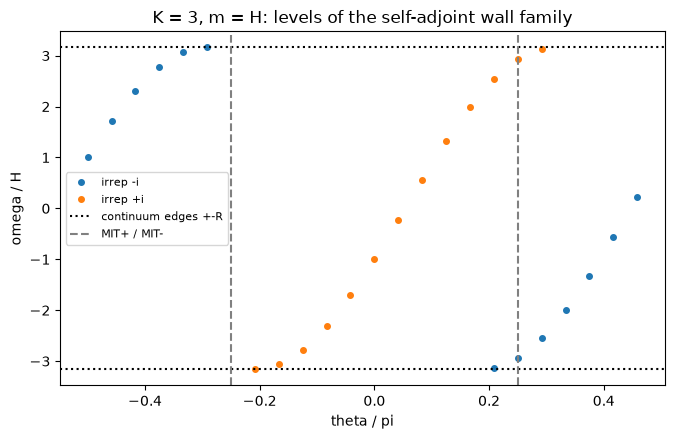

In [12]:
th3, th80 = dev_rows('waveguide_theta_K3.csv'), dev_rows('waveguide_theta_K80.csv')
print(f'{len(set(r["theta"] for r in th3))} values of theta at K = 3, {len(set(r["theta"] for r in th80))} at K = 80')
write_table('nb07_theta.csv', ['K', 'theta', 'omega', 'irrep'], [[r['K'], r['theta'], r['omega'], r['irrep']] for r in th3 + th80])
for thv, lab in ((-math.pi / 2, 'g(0) = 0'), (-math.pi / 4, 'MIT+'), (0.0, 'f(0) = 0'), (math.pi / 4, 'MIT-')):
    a = sorted(r['omega'] for r in th80 if abs(r['theta'] - thv) < 1e-9 and r['irrep'] == '-i')
    b = sorted(r['omega'] for r in th80 if abs(r['theta'] - thv) < 1e-9 and r['irrep'] == '+i')
    low = min([w for w in a + b if w > 0], default=float('nan'))
    print(f'K = 80, theta = {thv / math.pi:+.2f} pi ({lab:8s}): -i {[round(w, 6) for w in a]} | +i {[round(w, 6) for w in b]};  lowest positive {low:.6f}')
lowest_gp = min(r['omega'] for r in th80 if abs(r['theta'] + math.pi / 2) < 1e-9 and r['omega'] > 0)
assert abs(lowest_gp - 1.0) < 1e-9          # the exact flat band omega = m of g(0) = 0
fig, ax = plt.subplots(figsize=(7.8, 4.6))
for irr, col in (('-i', 'tab:blue'), ('+i', 'tab:orange')):
    P_ = np.array([(r['theta'] / math.pi, r['omega']) for r in th3 if r['irrep'] == irr])
    ax.plot(P_[:, 0], P_[:, 1], 'o', color=col, ms=4, label=f'irrep {irr}')
R3 = math.hypot(1.0, 3.0)
ax.axhline(R3, color='k', ls=':'); ax.axhline(-R3, color='k', ls=':', label='continuum edges +-R')
ax.axvline(-0.25, color='0.5', ls='--', label='MIT+ / MIT-'); ax.axvline(0.25, color='0.5', ls='--')
ax.set_xlabel('theta / pi'); ax.set_ylabel('omega / H'); ax.set_title('K = 3, m = H: levels of the self-adjoint wall family'); ax.legend(fontsize=8)
fig.savefig(RESULTS / 'nb07_theta.png', dpi=130, bbox_inches='tight'); print('figure: results/nb07_theta.png'); plt.show()

### 5.10 The wavefunctions of the ground level n = 0 and the first excited level n = 1 at `K = 80`

`waveguide.wavefunction` builds the normalized orbital (`∫ (f² + g²) dz = 1` in `L²(dz)`) from the left and
right Prüfer solutions with the exact exponential tail.  The cell computes n = 0 (irrep `−i`) and n = 1
(irrep `+i`) of the same-sign wall at `K = 80`, prints the norm on a long grid, the wall condition
`f(0) = g(0)`, the scalar density `∫ (f² − g²) dz` and the nodes, and writes `results/nb07_wavefunctions.csv`
and `results/nb07_wavefunctions.png`.

n = 0 (irrep -i), omega = 70.9853072299: norm = 0.999999999816, wall f(0) - g(0) = 0.0e+00, Int(f^2 - g^2) dz = 0.24150473, nodes f: 0, g: 0, decay kappa = 36.9065


n = 1 (irrep +i), omega = 78.1442493324: norm = 0.999999998828, wall f(0) - g(0) = 0.0e+00, Int(f^2 - g^2) dz = 0.01572127, nodes f: 0, g: 1, decay kappa = 17.1603
written: results/nb07_wavefunctions.csv
figure: results/nb07_wavefunctions.png


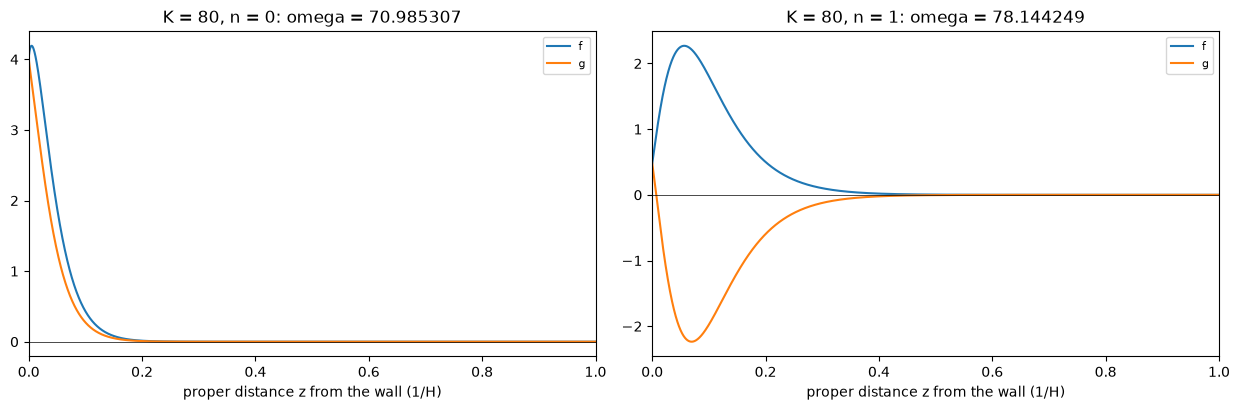

In [13]:
zs = wg.make_grid(0.0, 4.0, 0.0005)
zl = wg.make_grid(0.0, 60.0, 0.0005)
WF, rows = {}, []
for n, (Ks, pick) in ((0, (80.0, LEV80[0][0])), (1, (-80.0, LEV80[1][0]))):
    blk = wg.Block(Kinf=Ks, m=1.0, theta=wg.theta_MIT(+1))
    lv, _ = wg.find_levels(blk)
    L = min(lv, key=lambda X: abs(X.w - pick))
    f, g, info = wg.wavefunction(blk, L.w, zs)
    fl, gl, _ = wg.wavefunction(blk, L.w, zl)
    norm = simpson(fl * fl + gl * gl, x=zl)
    scal = simpson(fl * fl - gl * gl, x=zl)
    nod = lambda y: int(np.sum(np.diff(np.sign(y[np.abs(y) > 1e-12])) != 0))
    WF[n] = (L.w, f, g)
    print(f'n = {n} (irrep {"-i" if Ks > 0 else "+i"}), omega = {L.w:.10f}: norm = {norm:.12f}, wall f(0) - g(0) = {fl[0] - gl[0]:.1e},'
          f' Int(f^2 - g^2) dz = {scal:.8f}, nodes f: {nod(fl)}, g: {nod(gl)}, decay kappa = {L.kappa:.4f}')
    assert abs(norm - 1) < 1e-6 and abs(fl[0] - gl[0]) < 1e-9
    rows += [[n, L.w, float(z_), float(a_), float(b_)] for z_, a_, b_ in zip(zs[::10], f[::10], g[::10])]
write_table('nb07_wavefunctions.csv', ['n', 'omega', 'z', 'f', 'g'], rows)
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.2))
for i, n in enumerate((0, 1)):
    w_, f, g = WF[n]
    ax[i].plot(zs, f, label='f'); ax[i].plot(zs, g, label='g'); ax[i].axhline(0, color='k', lw=0.5)
    ax[i].set_xlim(0, 1.0); ax[i].set_xlabel('proper distance z from the wall (1/H)'); ax[i].set_title(f'K = 80, n = {n}: omega = {w_:.6f}'); ax[i].legend(fontsize=8)
fig.tight_layout(); fig.savefig(RESULTS / 'nb07_wavefunctions.png', dpi=130, bbox_inches='tight'); print('figure: results/nb07_wavefunctions.png'); plt.show()

### 5.11 Kohn–Sham along x0: the author's mass term is free, and its wall levels are exact

For `W = m0 σ` (the author's `V = −(2M/H) s`, `m0 = −2M`) the action is bilinear: the theory is free, the
single-particle levels above are its exact spectrum, and every many-body eigenstate is a Slater
determinant of them; no self-consistency is needed.  The cell lists the positive levels of both irreps
of the same-sign wall at `K = 0, 1, 3, 6, 6.7, 7, 10` (`m0 = H = 1`): none below `K_c(1)`, while the bulk
continuum starts at `m0`.  So the ground state of `N_s` fermions of the free theory has no fermion bound
to a same-sign wall; its wall levels are excited states.  At an opposite-sign wall the edge band lies
below `m0` up to `K*` (5.8), and the free ground state of up to `(4/(6π²)) K*³` fermions per unit
coordinate 3-volume is a Fermi sea of massless fermions bound to the wall.

In [14]:
rows = []
for K in (0.0, 1.0, 3.0, 6.0, 6.7, 7.0, 10.0):
    Kx = max(K, 1e-9)
    pos = sorted([L.w for L in wg.find_levels(wg.Block(Kinf=Kx, m=M0, theta=wg.theta_MIT(+1)))[0] if L.w > 0]
                 + [L.w for L in wg.find_levels(wg.Block(Kinf=-Kx, m=M0, theta=wg.theta_MIT(+1)))[0] if L.w > 0])
    rows.append([K, math.hypot(M0, K), len(pos), pos[0] if pos else float('nan')])
    print(f'same-sign wall, K = {K:5.2f}: bound positive levels {[round(w, 6) for w in pos]}; continuum from {math.hypot(M0, K):.6f}')
    assert (len(pos) == 0) == (K < THR[1.0]['Kc1_over_H'])
print(f'no same-sign wall level below K_c(1) = {THR[1.0]["Kc1_over_H"]:.8f}: every wall level lies above m0 = {M0} by at least'
      f' sqrt(m0^2 + K_c(1)^2) - m0 = {math.hypot(M0, THR[1.0]["Kc1_over_H"]) - M0:.6f}')
print(f'opposite-sign wall: the edge band lies below m0 for K < K* = {K_STAR:.6f}; free ground state bound to the wall for N_s <= {NS_MAX:.6f}')
write_table('nb07_free_levels.csv', ['K', 'R_continuum', 'n_bound_positive', 'lowest_positive'], rows)

same-sign wall, K =  0.00: bound positive levels []; continuum from 1.000000
same-sign wall, K =  1.00: bound positive levels []; continuum from 1.414214


same-sign wall, K =  3.00: bound positive levels []; continuum from 3.162278


same-sign wall, K =  6.00: bound positive levels []; continuum from 6.082763
same-sign wall, K =  6.70: bound positive levels []; continuum from 6.774216


same-sign wall, K =  7.00: bound positive levels [7.070615]; continuum from 7.071068


same-sign wall, K = 10.00: bound positive levels [9.999205]; continuum from 10.049876
no same-sign wall level below K_c(1) = 6.70624065: every wall level lies above m0 = 1.0 by at least sqrt(m0^2 + K_c(1)^2) - m0 = 5.780388
opposite-sign wall: the edge band lies below m0 for K < K* = 1.019715; free ground state bound to the wall for N_s <= 0.071622
written: results/nb07_free_levels.csv


### 5.12 The opposite-sign wall with `W = m0 σ + (λ/2) σ²`: a variationally consistent ground state

`m0 = 1`, `N_s = 0.05` per unit coordinate 3-volume, at the solver's full resolution (`Z = 30/H`,
`h_near = 0.003/H`, 16 Gauss–Legendre nodes, 31 k-points on `[0, 3]`), for `λ = −0.01` (this cell) and
`λ = −10` (the next).  The occupied band is the edge band of irrep `+i`, which starts at `ω = 0, k = 0`
without a threshold.  If `μ < m0`, every state below the Fermi level is a bound wall state, and the
configuration is a genuine ground state of `N_s` fermions.  The Walecka check evaluates
`Ω[m] = Σ_occ ω[m] + ∫ (m − m0)²/(2|λ|) dz/Sin` along `m = m0 + s (m_sc − m0)`, `s = 0.98, 1, 1.02`:
`Ω(1) = E`; a vanishing slope and a positive curvature make the self-consistent state stationary and a
minimum.  `E/N` is compared with a massless gas, `(3/4) μ`.

In [15]:
OPP = {}
LAM_O = -0.01
t0 = time.time()
r = wg.ks_solve(0.05, m0=M0, lam=LAM_O, eps=-1, kgrid=KG_OPP, tol=1e-10, verbose=False)
wc = wg.walecka_check(r, M0, LAM_O, -1, 0.05, KG_OPP)
s_ = ks_summary(r, 0.05)
slope_w = (wc[2][1] - wc[0][1]) / 0.04
curv_w = 0.5 * (wc[0][1] + wc[2][1]) - wc[1][1]
OPP[LAM_O] = dict(res=r, summary=s_, slope=slope_w, curvature=curv_w)
print(f'lam = {LAM_O}: converged = {r.converged} in {r.iterations} iterations; E/A = {r.E_per_A:.12f}; mu = {r.mu:.10f}; E/N = {s_["E_per_N"]:.8f};'
      f' band {r.occupations[0]["band"]}: k in [{s_["k_lo"]:.6f}, {s_["kF"]:.8f}]  ({time.time() - t0:.1f} s)')
print(f'   sigma in [{r.sigma.min():.4e}, {r.sigma.max():.4e}] (negative: f ~ -g for edge states); m in [{r.m.min():.8f}, {r.m.max():.8f}]'
      f' (the attraction RAISES m near the wall); interaction / kinetic energy = {r.E_int / r.sum_omega:.2e}')
print(f'   mu < m0: {r.mu < M0} (every state below mu is a bound wall state);  E/N / ((3/4) mu) = {s_["E_per_N"] / (0.75 * r.mu):.6f}')
print(f'   Walecka: Omega(0.98, 1, 1.02) = {wc[0][1]:.14f}, {wc[1][1]:.14f}, {wc[2][1]:.14f};  slope {slope_w:.2e}, curvature {curv_w:.2e}'
      f' -> stationary and a minimum;  Omega(1) - E/A = {wc[1][1] - r.E_per_A:.1e}')
assert r.converged and r.mu < M0 and abs(slope_w) < 1e-9 and curv_w > 0 and abs(wc[1][1] - r.E_per_A) < 1e-10

lam = -0.01: converged = True in 3 iterations; E/A = 0.033268937058; mu = 0.8871343842; E/N = 0.66537874; band n=0 (+i, j=1): k in [0.000000, 0.90459393]  (36.0 s)
   sigma in [-7.9639e-04, 9.6308e-24] (negative: f ~ -g for edge states); m in [1.00000000, 1.00000796] (the attraction RAISES m near the wall); interaction / kinetic energy = 4.23e-08
   mu < m0: True (every state below mu is a bound wall state);  E/N / ((3/4) mu) = 1.000042
   Walecka: Omega(0.98, 1, 1.02) = 0.03326893705838, 0.03326893705781, 0.03326893705838;  slope -1.18e-14, curvature 5.62e-13 -> stationary and a minimum;  Omega(1) - E/A = 1.9e-15


The same with `λ = −10`: a thousand times stronger attraction changes the edge-band ground state only
slightly, because the edge fermions have a small scalar density of the opposite sign.  The two profiles
go to `results/nb07_ks_opposite.csv`.

In [16]:
LAM_O = -10.0
t0 = time.time()
r = wg.ks_solve(0.05, m0=M0, lam=LAM_O, eps=-1, kgrid=KG_OPP, tol=1e-10, verbose=False)
wc = wg.walecka_check(r, M0, LAM_O, -1, 0.05, KG_OPP)
s_ = ks_summary(r, 0.05)
slope_w = (wc[2][1] - wc[0][1]) / 0.04
curv_w = 0.5 * (wc[0][1] + wc[2][1]) - wc[1][1]
OPP[LAM_O] = dict(res=r, summary=s_, slope=slope_w, curvature=curv_w)
print(f'lam = {LAM_O}: converged = {r.converged} in {r.iterations} iterations; E/A = {r.E_per_A:.12f}; mu = {r.mu:.10f}; E/N = {s_["E_per_N"]:.8f};'
      f' band {r.occupations[0]["band"]}: k in [{s_["k_lo"]:.6f}, {s_["kF"]:.8f}]  ({time.time() - t0:.1f} s)')
print(f'   sigma in [{r.sigma.min():.4e}, {r.sigma.max():.4e}] (negative: f ~ -g for edge states); m in [{r.m.min():.8f}, {r.m.max():.8f}]'
      f' (the attraction RAISES m near the wall); interaction / kinetic energy = {r.E_int / r.sum_omega:.2e}')
print(f'   mu < m0: {r.mu < M0} (every state below mu is a bound wall state);  E/N / ((3/4) mu) = {s_["E_per_N"] / (0.75 * r.mu):.6f}')
print(f'   Walecka: Omega(0.98, 1, 1.02) = {wc[0][1]:.14f}, {wc[1][1]:.14f}, {wc[2][1]:.14f};  slope {slope_w:.2e}, curvature {curv_w:.2e}'
      f' -> stationary and a minimum;  Omega(1) - E/A = {wc[1][1] - r.E_per_A:.1e}')
assert r.converged and r.mu < M0 and abs(slope_w) < 1e-9 and curv_w > 0 and abs(wc[1][1] - r.E_per_A) < 1e-10

write_table('nb07_ks_opposite.csv', ['lam', 'z', 'sigma', 'm', 'n'],
            [[lam_, float(z_), float(s_v), float(m_v), float(n_v)] for lam_, d in OPP.items() for z_, s_v, m_v, n_v in zip(d['res'].z[::5], d['res'].sigma[::5], d['res'].m[::5], d['res'].n[::5])])

lam = -10.0: converged = True in 6 iterations; E/A = 0.033267529405; mu = 0.8870591549; E/N = 0.66535059; band n=0 (+i, j=1): k in [0.000000, 0.90459393]  (48.5 s)
   sigma in [-7.9856e-04, 0.0000e+00] (negative: f ~ -g for edge states); m in [1.00000000, 1.00798557] (the attraction RAISES m near the wall); interaction / kinetic energy = 4.24e-05
   mu < m0: True (every state below mu is a bound wall state);  E/N / ((3/4) mu) = 1.000085
   Walecka: Omega(0.98, 1, 1.02) = 0.03326752996900, 0.03326752940537, 0.03326752996900;  slope 2.00e-13, curvature 5.64e-10 -> stationary and a minimum;  Omega(1) - E/A = -1.2e-14
written: results/nb07_ks_opposite.csv


### 5.13 The same-sign wall, `λ = −0.01`, `N_s = 100`: a converged configuration that is not a variational minimum

`m0 = 1`, `λ = −0.01` (attractive; the cell prints the depth of the mass depression it causes), `N_s = 100`,
which fills the bare n = 0 band well above `K_c(1)`.  This notebook runs it at the reduced resolution
printed by the helper cell (`h_near = 0.006/H`, 12 Gauss–Legendre nodes, 21 k-points on `[0, 20]`, `Z = 30/H`);
5.17 compares every number with the solver's full resolution.  The first cell solves the ground state
of the wall-band sector (common Fermi level) and prints the profile; the second is the Walecka check,
and it explains the slope it finds: the band bottom `k_lo` is a continuum threshold below `μ`, so a
deeper well pulls new bound states out of the continuum at the band bottom (energy `R(k_lo)`), and
they replace Fermi-surface states at `μ`, a change `(4/(2π²)) k_lo² (−dk_lo/ds)(R(k_lo) − μ)` per unit `s`.
The same `μ > m0` also puts bulk continuum states below the Fermi level.  The third cell repeats the
ground state with `Z = 45/H` to show the truncation of the mass profile at `Z`.

In [17]:
t0 = time.time()
GS = wg.ks_solve(100.0, m0=M0, lam=LAM, eps=+1, kgrid=KG_SAME, tol=1e-8, verbose=False, **RED)
GSs = ks_summary(GS, 100.0)
print(f'converged = {GS.converged} in {GS.iterations} iterations ({time.time() - t0:.1f} s): E/A = {GS.E_per_A:.8f} (sum omega {GS.sum_omega:.8f} + interaction {GS.E_int:.8f});'
      f' E/N = {GSs["E_per_N"]:.8f}; mu = {GS.mu:.8f}')
for o in GS.occupations:
    print(f'   {o["band"]}: k in [{o["k_lo"]:.6f}, {o["kF"]:.6f}], N = {o["N"]:.6f}, band bottom omega = {o["w_bottom"]:.6f}')
print(f'   bare threshold K_c(1) = {THR[1.0]["Kc1_over_H"]:.6f} -> self-consistent band bottom k_lo = {GSs["k_lo"]:.6f}: the attractive field binds the band down to lower k')
print(f'   sigma_max = {GSs["sigma_ext"]:.6f} at z = {GSs["z_ext"]:.4f}; m_min = {GSs["m_min"]:.6f}; interaction / kinetic = {GS.E_int / GS.sum_omega:.2e}')
print(f'   mu - m0 = {GS.mu - M0:.4f} > 0: bulk continuum states (omega >= m0) lie below the Fermi level -- not the global ground state')
for z_ in (0.01, 0.05, 0.1, 0.167, 0.25, 0.4, 0.6, 1.0, 2.0, 5.0, 10.0, 30.0):
    i = int(np.argmin(np.abs(GS.z - z_)))
    print(f'      z = {GS.z[i]:7.3f}   sigma = {GS.sigma[i]:10.6f}   m = {GS.m[i]:.8f}   n = {GS.n[i]:10.4f}')
assert GS.converged and GS.mu > M0 and len(GS.occupations) == 1

converged = True in 8 iterations (31.6 s): E/A = 937.22904016 (sum omega 936.05530498 + interaction 1.17373518); E/N = 9.37229040; mu = 11.69590358
   n=0 (-i, j=0): k in [5.459020, 11.800221], N = 100.000000, band bottom omega = 5.549856
   bare threshold K_c(1) = 6.706241 -> self-consistent band bottom k_lo = 5.459020: the attractive field binds the band down to lower k
   sigma_max = 23.842367 at z = 0.1639; m_min = 0.761576; interaction / kinetic = 1.25e-03
   mu - m0 = 10.6959 > 0: bulk continuum states (omega >= m0) lie below the Fermi level -- not the global ground state
      z =   0.010   sigma =   2.584097   m = 0.97415903   n =    56.9023
      z =   0.050   sigma =  13.750869   m = 0.86249131   n =   114.0709
      z =   0.098   sigma =  21.127831   m = 0.78872169   n =   133.5902
      z =   0.170   sigma =  23.841988   m = 0.76158012   n =   130.4128
      z =   0.248   sigma =  22.124550   m = 0.77875450   n =   113.9217
      z =   0.398   sigma =  16.474600   m = 0.835

The Walecka check of this configuration along `m = m0 + s (m_sc − m0)`, and the threshold term that
accounts for its slope (the same reduced resolution).

In [18]:
t0 = time.time()
WC = wg.walecka_check(GS, M0, LAM, +1, 100.0, KG_SAME, Z=RED['Z'], h_near=RED['h_near'], n_gl=RED['n_gl'])
for sc, Om_, mu_s, bl in WC:
    print(f'   s = {sc:.2f}: Omega = {Om_:.8f}, mu = {mu_s:.8f}, ' + '; '.join(f'{l}: k_lo = {kl:.6f}, omega_bottom = {wb:.6f}' for l, kl, wb in bl))
W_SLOPE = (WC[2][1] - WC[0][1]) / (WC[2][0] - WC[0][0])
b_lo = [x for x in WC[1][3] if x[0].startswith('n=0')][0]
dklo = ([x for x in WC[2][3] if x[0].startswith('n=0')][0][1] - [x for x in WC[0][3] if x[0].startswith('n=0')][0][1]) / (WC[2][0] - WC[0][0])
W_THR = 4.0 / (2 * PI2) * b_lo[1] ** 2 * (-dklo) * (b_lo[2] - GS.mu)
print(f'dOmega/ds = {W_SLOPE:.6f}: NOT stationary;  threshold term (4/2pi^2) k_lo^2 (-dk_lo/ds) (R(k_lo) - mu) = {W_THR:.6f} (dk_lo/ds = {dklo:.6f}); Omega(1) - E/A = {WC[1][1] - GS.E_per_A:.1e}  ({time.time() - t0:.1f} s)')
assert W_SLOPE < 0 and abs(W_THR / W_SLOPE - 1) < 2e-2 and abs(WC[1][1] - GS.E_per_A) < 1e-5

   s = 0.98: Omega = 938.19764747, mu = 11.70187764, n=0 (-i, j=0): k_lo = 5.485022, omega_bottom = 5.575434
   s = 1.00: Omega = 937.22903973, mu = 11.69590357, n=0 (-i, j=0): k_lo = 5.459020, omega_bottom = 5.549856
   s = 1.02: Omega = 936.26548180, mu = 11.68996431, n=0 (-i, j=0): k_lo = 5.432964, omega_bottom = 5.524228
dOmega/ds = -48.304142: NOT stationary;  threshold term (4/2pi^2) k_lo^2 (-dk_lo/ds) (R(k_lo) - mu) = -48.304504 (dk_lo/ds = -1.301464); Omega(1) - E/A = -4.3e-07  (11.5 s)


The truncation of the mass profile at `Z` (beyond it `m = m0`) is not negligible, because orbitals near the
band threshold decay slowly and leave an inverse-square density tail.  The same ground state with
`Z = 45/H` (same reduced resolution otherwise):

In [19]:
t0 = time.time()
GS45 = wg.ks_solve(100.0, m0=M0, lam=LAM, eps=+1, kgrid=KG_SAME, tol=1e-8, verbose=False, Z=45.0, h_near=RED['h_near'], n_gl=RED['n_gl'])
d_EA, d_mu = GS45.E_per_A - GS.E_per_A, GS45.mu - GS.mu
print(f'Z = 45: E/A = {GS45.E_per_A:.8f} (Z = 30: {GS.E_per_A:.8f}; difference {d_EA:+.6f}, {d_EA / GS.E_per_A:+.2e} relative); mu = {GS45.mu:.8f} ({d_mu:+.2e});'
      f' k_lo = {GS45.occupations[0]["k_lo"]:.6f}  ({time.time() - t0:.1f} s)')
i = int(np.argmin(np.abs(GS45.z - 10.0))); j = int(np.argmin(np.abs(GS45.z - 20.0)))
print(f'density tail: sigma(20)/sigma(10) = {GS45.sigma[j] / GS45.sigma[i]:.4f} (an inverse-square tail gives 0.25)')
assert GS45.converged and d_EA < 0

Z = 45: E/A = 937.06107832 (Z = 30: 937.22904016; difference -0.167962, -1.79e-04 relative); mu = 11.69499658 (-9.07e-04); k_lo = 5.454492  (44.0 s)
density tail: sigma(20)/sigma(10) = 0.2529 (an inverse-square tail gives 0.25)


### 5.14 The band gap at fixed transverse momentum in the self-consistent potential

The first excited level at a given transverse momentum `k` is the next level of the 16-component problem
in the self-consistent mass profile of 5.13 (interpolated onto a grid with `h_near = 0.001/H`, as the solver does).  The
cell prints the positive levels and the gap `ω_1 − ω_0` at `k = 34, 40, 60, 80`, next to the bare wall's
gap from the dispersion table of 5.7.

In [20]:
Gsc = wg.KSGrid(Z=30.0, h_near=0.001, theta=wg.theta_MIT(+1))
Gsc.set_mass(PchipInterpolator(GS.z, GS.m)(Gsc.z), M0)
rows, GAPS = [], {}
for k in (34.0, 40.0, 60.0, 80.0):
    allp = sorted([(w, '-i') for (_, j, w, _) in Gsc.levels(np.array([k]), +1)] + [(w, '+i') for (_, j, w, _) in Gsc.levels(np.array([k]), -1)])
    bare = sorted(r['omega'] for r in disp if r['K'] == k)
    gap_sc, gap_bare = allp[1][0] - allp[0][0], bare[1] - bare[0]
    GAPS[k] = gap_sc
    rows.append([k, allp[0][0], allp[1][0], gap_sc, gap_bare])
    print(f'k = {k:5.1f}: self-consistent levels {[(round(w, 6), i) for w, i in allp]}; gap = {gap_sc:.6f} (bare wall {gap_bare:.6f})')
    assert gap_sc > 0
write_table('nb07_band_gap.csv', ['k', 'omega0_sc', 'omega1_sc', 'gap_sc', 'gap_bare'], rows)

k =  34.0: self-consistent levels [(31.927594, '-i'), (34.012728, '+i')]; gap = 2.085134 (bare wall 2.052432)


k =  40.0: self-consistent levels [(37.181561, '-i'), (39.961806, '+i')]; gap = 2.780245 (bare wall 2.753163)


k =  60.0: self-consistent levels [(54.297126, '-i'), (59.320809, '+i'), (59.921804, '-i')]; gap = 5.023683 (bare wall 4.996295)


k =  80.0: self-consistent levels [(70.966117, '-i'), (78.150975, '+i'), (79.366712, '-i'), (79.984381, '+i')]; gap = 7.184858 (bare wall 7.158942)
written: results/nb07_band_gap.csv


### 5.15 The ΔSCF first excited state: a fraction `x` of the fermions in band n = 1

The first excited state of the same-sign wall-band sector, by ΔSCF: a fraction `x` of `N_s` occupies band
n = 1 (irrep `+i`), the rest band n = 0, each filled from its bottom (the lowest configuration with these
occupations), solved self-consistently from the ground-state profile (reduced resolution, 41 k-points on
`[0, 40]`, tolerance `1e−7`).  `ΔE/A` divided by the number of promoted fermions `x N_s` is the excitation
energy per promoted fermion; `x → 0` is the lowest ΔSCF excitation.  One value of `x` per cell (under a
minute each): 0.01, 0.05, 0.10, 0.20.

In [21]:
DSCF = {}
t0 = time.time()
x_ = 0.01
r = wg.ks_solve(100.0, m0=M0, lam=LAM, eps=+1, kgrid=KG_DSCF, fractions={0: 1 - x_, 1: x_}, tol=1e-7, m_init=GS.m, verbose=False, **RED)
dE = r.E_per_A - GS.E_per_A
DSCF[x_] = dict(res=r, dE=dE, per=dE / (x_ * 100.0))
print(f'x = {x_}: converged = {r.converged} in {r.iterations} iterations: E/A = {r.E_per_A:.8f}; Delta E/A = {dE:.8f}; per promoted fermion {dE / (x_ * 100.0):.8f}  ({time.time() - t0:.1f} s)')
for o in r.occupations:
    print(f'   {o["band"]}: k in [{o["k_lo"]:.6f}, {o["kF"]:.6f}], N = {o["N"]:.4f}, top omega = {o["w_top"]:.6f}')
assert r.converged and dE > 0

top0 = GS.occupations[0]
b1 = [o for o in DSCF[0.01]['res'].occupations if o['band'].startswith('n=1')][0]
print(f'compare: bottom of band n = 1, sqrt(m0^2 + k_lo^2) = {math.hypot(M0, b1["k_lo"]):.6f}, minus the Fermi level mu = {GS.mu:.6f}:'
      f' {math.hypot(M0, b1["k_lo"]) - GS.mu:.4f}; the rest of the excitation energy is the rearrangement of the mean field')

x = 0.01: converged = True in 5 iterations: E/A = 957.98040214; Delta E/A = 20.75136197; per promoted fermion 20.75136197  (40.0 s)
   n=0 (-i, j=0): k in [5.470843, 11.767225], N = 99.0000, top omega = 11.609682
   n=1 (+i, j=0): k in [31.975525, 31.980351], N = 1.0000, top omega = 31.995938
compare: bottom of band n = 1, sqrt(m0^2 + k_lo^2) = 31.991159, minus the Fermi level mu = 11.695904: 20.2953; the rest of the excitation energy is the rearrangement of the mean field


ΔSCF with `x = 0.05` of `N_s` in band n = 1 (the same resolution and starting profile).  With more
fermions promoted the well weakens and the n = 1 shell fills, so the energy per promoted fermion grows.

In [22]:
t0 = time.time()
x_ = 0.05
r = wg.ks_solve(100.0, m0=M0, lam=LAM, eps=+1, kgrid=KG_DSCF, fractions={0: 1 - x_, 1: x_}, tol=1e-7, m_init=GS.m, verbose=False, **RED)
dE = r.E_per_A - GS.E_per_A
DSCF[x_] = dict(res=r, dE=dE, per=dE / (x_ * 100.0))
print(f'x = {x_}: converged = {r.converged} in {r.iterations} iterations: E/A = {r.E_per_A:.8f}; Delta E/A = {dE:.8f}; per promoted fermion {dE / (x_ * 100.0):.8f}  ({time.time() - t0:.1f} s)')
for o in r.occupations:
    print(f'   {o["band"]}: k in [{o["k_lo"]:.6f}, {o["kF"]:.6f}], N = {o["N"]:.4f}, top omega = {o["w_top"]:.6f}')
assert r.converged and dE > 0

x = 0.05: converged = True in 6 iterations: E/A = 1041.82304286; Delta E/A = 104.59400270; per promoted fermion 20.91880054  (47.5 s)
   n=0 (-i, j=0): k in [5.517339, 11.633288], N = 95.0000, top omega = 11.485587
   n=1 (+i, j=0): k in [32.079320, 32.103279], N = 5.0000, top omega = 32.118629


ΔSCF with `x = 0.10` of `N_s` in band n = 1 (the same resolution and starting profile).  With more
fermions promoted the well weakens and the n = 1 shell fills, so the energy per promoted fermion grows.

In [23]:
t0 = time.time()
x_ = 0.10
r = wg.ks_solve(100.0, m0=M0, lam=LAM, eps=+1, kgrid=KG_DSCF, fractions={0: 1 - x_, 1: x_}, tol=1e-7, m_init=GS.m, verbose=False, **RED)
dE = r.E_per_A - GS.E_per_A
DSCF[x_] = dict(res=r, dE=dE, per=dE / (x_ * 100.0))
print(f'x = {x_}: converged = {r.converged} in {r.iterations} iterations: E/A = {r.E_per_A:.8f}; Delta E/A = {dE:.8f}; per promoted fermion {dE / (x_ * 100.0):.8f}  ({time.time() - t0:.1f} s)')
for o in r.occupations:
    print(f'   {o["band"]}: k in [{o["k_lo"]:.6f}, {o["kF"]:.6f}], N = {o["N"]:.4f}, top omega = {o["w_top"]:.6f}')
assert r.converged and dE > 0

x = 0.1: converged = True in 6 iterations: E/A = 1148.47935093; Delta E/A = 211.25031077; per promoted fermion 21.12503108  (47.4 s)
   n=0 (-i, j=0): k in [5.573911, 11.461293], N = 90.0000, top omega = 11.325871
   n=1 (+i, j=0): k in [32.203950, 32.251463], N = 10.0000, top omega = 32.266524


ΔSCF with `x = 0.20` of `N_s` in band n = 1 (the same resolution and starting profile).  With more
fermions promoted the well weakens and the n = 1 shell fills, so the energy per promoted fermion grows.

In [24]:
t0 = time.time()
x_ = 0.20
r = wg.ks_solve(100.0, m0=M0, lam=LAM, eps=+1, kgrid=KG_DSCF, fractions={0: 1 - x_, 1: x_}, tol=1e-7, m_init=GS.m, verbose=False, **RED)
dE = r.E_per_A - GS.E_per_A
DSCF[x_] = dict(res=r, dE=dE, per=dE / (x_ * 100.0))
print(f'x = {x_}: converged = {r.converged} in {r.iterations} iterations: E/A = {r.E_per_A:.8f}; Delta E/A = {dE:.8f}; per promoted fermion {dE / (x_ * 100.0):.8f}  ({time.time() - t0:.1f} s)')
for o in r.occupations:
    print(f'   {o["band"]}: k in [{o["k_lo"]:.6f}, {o["kF"]:.6f}], N = {o["N"]:.4f}, top omega = {o["w_top"]:.6f}')
assert r.converged and dE > 0

x = 0.2: converged = True in 6 iterations: E/A = 1367.82110028; Delta E/A = 430.59206012; per promoted fermion 21.52960301  (46.5 s)
   n=0 (-i, j=0): k in [5.683340, 11.100799], N = 80.0000, top omega = 10.989841
   n=1 (+i, j=0): k in [32.438380, 32.531906], N = 20.0000, top omega = 32.546408


The ΔSCF table and the Kohn–Sham profiles: `σ(z)`, `m(z)` and `n(z)` of the same-sign ground state, of the
ΔSCF state with `x = 0.10`, and of the opposite-sign edge-band ground state (`λ = −10`).  Written to
`results/nb07_dscf.csv`, `results/nb07_ks_same.csv` and `results/nb07_ks_profiles.png`.

Delta E per promoted fermion: x = 0.01: 20.751362, x = 0.05: 20.918801, x = 0.1: 21.125031, x = 0.2: 21.529603
written: results/nb07_dscf.csv
written: results/nb07_ks_same.csv


figure: results/nb07_ks_profiles.png


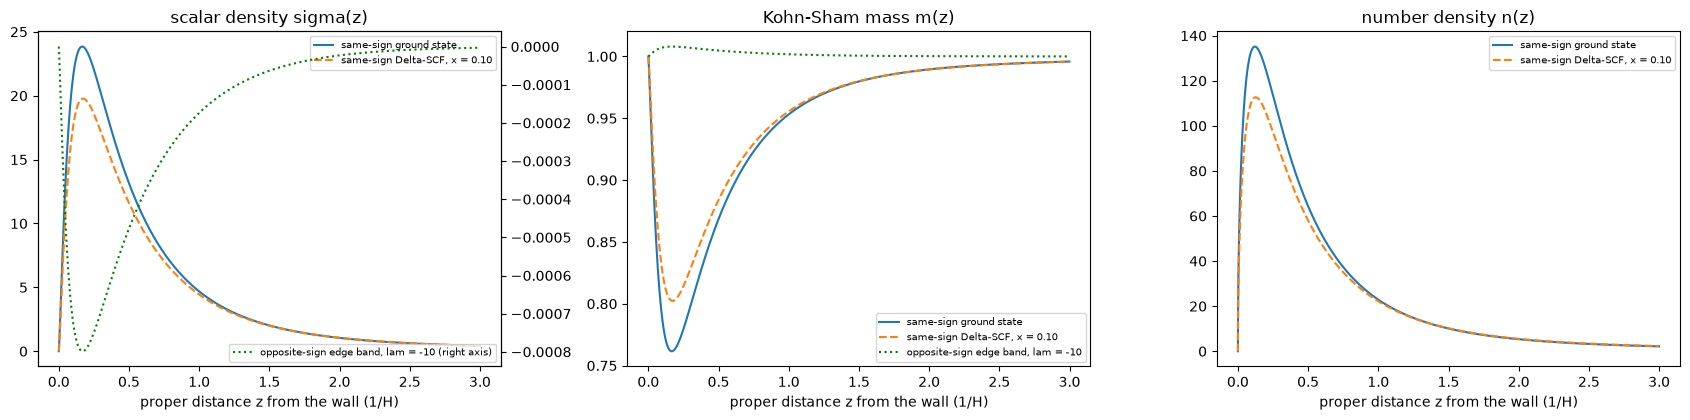

In [25]:
xs_ = sorted(DSCF)
pers = [DSCF[x]['per'] for x in xs_]
print('Delta E per promoted fermion: ' + ', '.join(f'x = {x:g}: {p:.6f}' for x, p in zip(xs_, pers)))
assert all(np.diff(pers) > 0)
write_table('nb07_dscf.csv', ['x', 'E_per_A', 'Delta_E_per_A', 'Delta_E_per_promoted'], [[x, DSCF[x]['res'].E_per_A, DSCF[x]['dE'], DSCF[x]['per']] for x in xs_])
write_table('nb07_ks_same.csv', ['state', 'z', 'sigma', 'm', 'n'],
            [[lab, float(z_), float(a_), float(b_), float(c_)] for lab, rr in (('ground state', GS), ('Delta-SCF x=0.10', DSCF[0.10]['res']))
             for z_, a_, b_, c_ in zip(rr.z[::5], rr.sigma[::5], rr.m[::5], rr.n[::5])])
fig, ax = plt.subplots(1, 3, figsize=(17, 4.3))
for lab, rr, ls in (('same-sign ground state', GS, '-'), ('same-sign Delta-SCF, x = 0.10', DSCF[0.10]['res'], '--')):
    sel = rr.z <= 3.0
    ax[0].plot(rr.z[sel], rr.sigma[sel], ls, label=lab); ax[1].plot(rr.z[sel], rr.m[sel], ls, label=lab); ax[2].plot(rr.z[sel], rr.n[sel], ls, label=lab)
ro = OPP[-10.0]['res']
sel = ro.z <= 3.0
ax0b = ax[0].twinx(); ax0b.plot(ro.z[sel], ro.sigma[sel], 'g:', label='opposite-sign edge band, lam = -10 (right axis)'); ax0b.legend(fontsize=7, loc='lower right')
ax[1].plot(ro.z[sel], ro.m[sel], 'g:', label='opposite-sign edge band, lam = -10')
for a_, t_ in zip(ax, ('scalar density sigma(z)', 'Kohn-Sham mass m(z)', 'number density n(z)')):
    a_.set_xlabel('proper distance z from the wall (1/H)'); a_.set_title(t_); a_.legend(fontsize=7)
fig.tight_layout(); fig.savefig(RESULTS / 'nb07_ks_profiles.png', dpi=130, bbox_inches='tight'); print('figure: results/nb07_ks_profiles.png'); plt.show()

### 5.16 Strong attraction at the same-sign wall: the self-consistency fails, and why

Can an attractive functional bind a genuinely stable layer (`μ < m0`) at the same-sign wall?  First,
homogeneous matter far from the wall (four spatial dimensions, 8 states per 4-momentum) is self-bound
only for strong attraction: `python waveguide.py dft --scenario bulk` scans `λ`.  Then the solver's
exploratory scenario `λ = −100`, `N_s = 0.03`, started from a well centred at `z = 1.5/H`, is run here at
reduced resolution (`Z = 40/H`, `h_near = 0.01/H`, 12 Gauss–Legendre nodes, 26 k-points on `[0, 2.5]`,
mixing 0.3) for twelve iterations, in two cells of six (the mixing history restarts between them).  The
residual stalls and rises again instead of converging, and the layer centre `z_c` wanders outward, away
from the wall, though not monotonically.  The third cell moves the
last well rigidly to other centres and evaluates the Walecka functional there (an upper bound on the
energy of a layer at that place): it decreases with the distance from the wall, so the wall repels the
layer and there is no wall-bound ground state to converge to.  The solver's full exploratory run
(`--scenario strong`, 60 iterations) is not repeated here.

In [26]:
out_bulk = run_wg('dft', '--scenario', 'bulk')
BULK = {float(a): (float(b), c) for a, b, c in re.findall(r'lam =\s+(-?[\d.]+): min over kF .*? = ([-+\d.]+) at kF .*?-> (SELF-BOUND|not self-bound)', out_bulk)}
LAM_BOUND = max(l for l, (e, c) in BULK.items() if c == 'SELF-BOUND')
print(f'homogeneous matter is self-bound for lam <= {LAM_BOUND:g} among the values scanned, not for lam >= {min(l for l, (e, c) in BULK.items() if c != "SELF-BOUND"):g}')
assert BULK[-0.01][1] != 'SELF-BOUND' and BULK[-100.0][1] == 'SELF-BOUND'
STRONG = dict(Ns=0.03, lam=-100.0, kgrid=np.linspace(0.0, 2.5, 26), Z=40.0, h_near=0.01, n_gl=12)
t0 = time.time()
S1 = wg.ks_solve(STRONG['Ns'], m0=M0, lam=STRONG['lam'], eps=+1, kgrid=STRONG['kgrid'], Z=STRONG['Z'], h_near=STRONG['h_near'], n_gl=STRONG['n_gl'],
                 m_init=lambda z: M0 - 0.6 * np.exp(-((z - 1.5) / 0.8) ** 2), mix=0.3, maxit=6, tol=1e-8, verbose=False)
print(f'iterations 1-6 ({time.time() - t0:.1f} s): residual max|m_new - m| = {[f"{h_["residual"]:.2e}" for h_ in S1.history]}; layer centre z_c = {[round(h_["zc"], 3) for h_ in S1.history]}; mu = {S1.mu:.6f}')

$ python fermion/waveguide.py dft --scenario bulk


waveguide.py dft   (python 3.14.5, numpy 2.5.3)

[DFT bulk] homogeneous 4D matter (z, x1..x3), g = 8 per 4-momentum, W = m0 sigma + (lam/2) sigma^2, m0 = 1:
   n = kF^4/(4 pi^2), sigma = (m/pi^2) Int_0^kF k^3/w, eps = (1/pi^2) Int_0^kF k^3 w, gap m = m0 + lam sigma, E = eps - (lam/2) sigma^2
   lam =    -0.01: min over kF in [0.01, 10] of (E/n - m0) = +0.000033 at kF = 0.0100, m* = 1.0000, n = 2.533e-10  -> not self-bound (minimum at the lowest density)
   lam =    -1.00: min over kF in [0.01, 10] of (E/n - m0) = +0.000033 at kF = 0.0100, m* = 1.0000, n = 2.533e-10  -> not self-bound (minimum at the lowest density)
   lam =   -10.00: min over kF in [0.01, 10] of (E/n - m0) = +0.000033 at kF = 0.0100, m* = 1.0000, n = 2.533e-10  -> not self-bound (minimum at the lowest density)
   lam =   -30.00: min over kF in [0.01, 10] of (E/n - m0) = +0.000033 at kF = 0.0100, m* = 1.0000, n = 2.533e-10  -> not self-bound (minimum at the lowest density)
   lam =   -60.00: min over kF in [0.01, 10] of

iterations 1-6 (38.1 s): residual max|m_new - m| = ['5.44e-01', '3.91e-01', '1.46e-01', '1.30e-01', '1.06e-01', '5.58e-02']; layer centre z_c = [2.074, 2.04, 2.094, 2.158, 2.445, 2.421]; mu = 0.878843


Iterations 7–12 of the same strong-coupling run, continued from the last mass profile of the previous
cell (the Anderson mixing history starts afresh):

In [27]:
t0 = time.time()
S2 = wg.ks_solve(STRONG['Ns'], m0=M0, lam=STRONG['lam'], eps=+1, kgrid=STRONG['kgrid'], Z=STRONG['Z'], h_near=STRONG['h_near'], n_gl=STRONG['n_gl'],
                 m_init=S1.m, mix=0.3, maxit=6, tol=1e-8, verbose=False)
hist = S1.history + S2.history
print(f'iterations 7-12 ({time.time() - t0:.1f} s): residual = {[f"{h_["residual"]:.2e}" for h_ in S2.history]}; z_c = {[round(h_["zc"], 3) for h_ in S2.history]}')
print(f'converged: {S2.converged};  after 12 iterations mu = {S2.mu:.6f} (mu - m0 = {S2.mu - M0:+.4f}: the layer is bound below the bulk continuum),'
      f' residual {hist[-1]["residual"]:.2e}; z_c moved from {hist[0]["zc"]:.3f} to {hist[-1]["zc"]:.3f}')
assert not S1.converged and not S2.converged and S2.mu < M0 and hist[-1]['zc'] > hist[0]['zc']

iterations 7-12 (36.7 s): residual = ['5.89e-02', '5.15e-02', '4.12e-02', '1.51e-01', '1.79e-01', '4.08e-02']; z_c = [2.542, 2.566, 2.664, 3.22, 2.115, 2.63]
converged: False;  after 12 iterations mu = 0.877390 (mu - m0 = -0.1226: the layer is bound below the bulk continuum), residual 4.08e-02; z_c moved from 2.074 to 2.630


The rigid-shift diagnostic: the last well `m(z) − m0` moved to the centres `z_c = 0.6, 1.5, 3, 6` (in `1/H`),
with the Walecka functional and the Fermi level evaluated there (same reduced resolution).  Written, with
the iteration history, to `results/nb07_strong.csv` and drawn in `results/nb07_strong.png`.

   well centred at z_c =  0.6: Omega = 0.03210457, mu = 0.985509


   well centred at z_c =  1.5: Omega = 0.02978771, mu = 0.898754


   well centred at z_c =  3.0: Omega = 0.02881729, mu = 0.869417


   well centred at z_c =  6.0: Omega = 0.02872024, mu = 0.866566
(23.6 s)  Omega decreases monotonically away from the wall: True -> the same-sign wall repels the layer
written: results/nb07_strong.csv


figure: results/nb07_strong.png


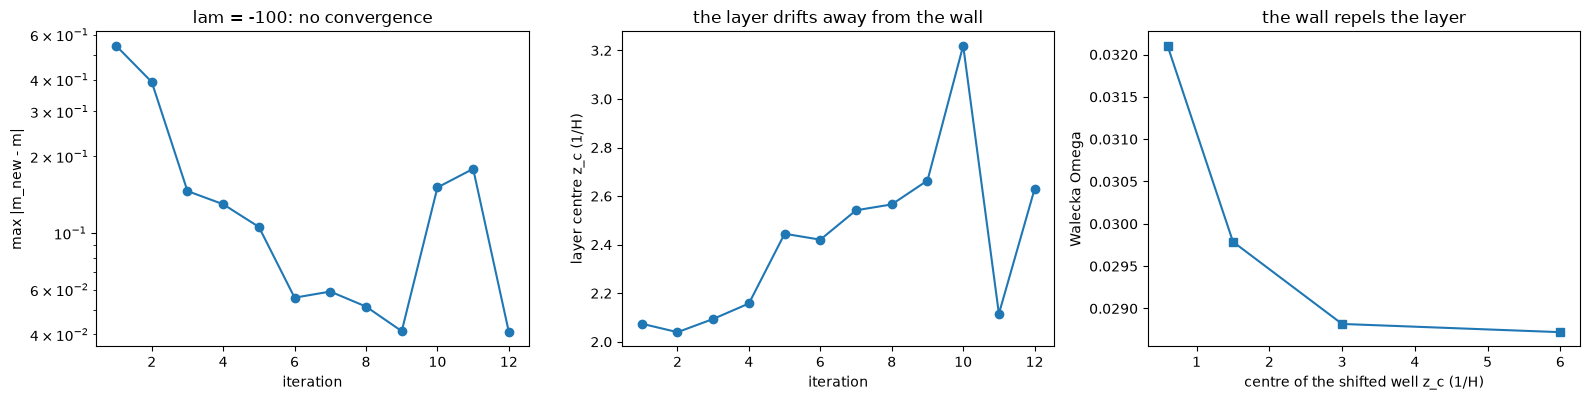

In [28]:
t0 = time.time()
zc0 = hist[-1]['zc']
dm_ = PchipInterpolator(S2.z, S2.m - M0, extrapolate=False)
SHIFT = []
for zc in (0.6, 1.5, 3.0, 6.0):
    Gs = wg.KSGrid(Z=STRONG['Z'], h_near=STRONG['h_near'], theta=wg.theta_MIT(+1))
    mn = M0 + np.nan_to_num(dm_(Gs.z - (zc - zc0)), nan=0.0)
    Om_, mu_ = wg.walecka_energy(Gs, mn, M0, STRONG['lam'], STRONG['Ns'], STRONG['kgrid'], n_gl=STRONG['n_gl'])
    SHIFT.append((zc, Om_, mu_))
    print(f'   well centred at z_c = {zc:4.1f}: Omega = {Om_:.8f}, mu = {mu_:.6f}')
print(f'({time.time() - t0:.1f} s)  Omega decreases monotonically away from the wall: {all(np.diff([s[1] for s in SHIFT]) < 0)} -> the same-sign wall repels the layer')
assert all(np.diff([s[1] for s in SHIFT]) < 0)
write_table('nb07_strong.csv', ['kind', 'index_or_zc', 'residual_or_Omega', 'zc_or_mu'],
            [['iteration', i + 1, h_['residual'], h_['zc']] for i, h_ in enumerate(hist)] + [['rigid shift', zc, Om_, mu_] for zc, Om_, mu_ in SHIFT])
fig, ax = plt.subplots(1, 3, figsize=(16, 4.1))
ax[0].semilogy(range(1, len(hist) + 1), [h_['residual'] for h_ in hist], 'o-'); ax[0].set_xlabel('iteration'); ax[0].set_ylabel('max |m_new - m|'); ax[0].set_title('lam = -100: no convergence')
ax[1].plot(range(1, len(hist) + 1), [h_['zc'] for h_ in hist], 'o-'); ax[1].set_xlabel('iteration'); ax[1].set_ylabel('layer centre z_c (1/H)'); ax[1].set_title('the layer drifts away from the wall')
ax[2].plot([s[0] for s in SHIFT], [s[1] for s in SHIFT], 's-'); ax[2].set_xlabel('centre of the shifted well z_c (1/H)'); ax[2].set_ylabel('Walecka Omega'); ax[2].set_title('the wall repels the layer')
fig.tight_layout(); fig.savefig(RESULTS / 'nb07_strong.png', dpi=130, bbox_inches='tight'); print('figure: results/nb07_strong.png'); plt.show()

### 5.17 The full-resolution runs of the solver, and the comparison

The background run `python waveguide.py dft` (started by the helper cell) computes the free levels, the
same-sign ground state with its Walecka check and band gaps, the four ΔSCF states, and the two
opposite-sign ground states, all at the solver's full resolution (`Z = 30/H`, `h_near = 0.003/H`, 16
Gauss–Legendre nodes, 41 k-points on `[0, 20]`, 81 on `[0, 40]` for ΔSCF, tolerance `1e−9`).  This cell waits
for it if it is still running (the one cell of the project that may take more than a minute), prints its
log, extracts its numbers into `results/nb07_dft_full.csv`, and compares them with this notebook's runs
in `results/nb07_dft_comparison.csv`.  The opposite-sign runs of 5.12 used the same resolution, so they must
agree to the digits the log prints (relative `1e−8`).  The same-sign runs used the reduced resolution, and
the table shows by how much that matters.  The cell asserts relative differences below `1e−4` for the
energies, the Fermi level, the band edges and the Walecka slope, `1e−5` for the ΔSCF energies, `1e−6` for the
band gaps, and `1e−3` for `sigma_max`, which is the largest value on the grid and so depends on the grid itself.

In [29]:
while FULL.poll() is None:
    time.sleep(2)
_full_fh.close()
full = FULL_LOG.read_text(encoding='utf-8')
print(full)
print(f'waveguide.py dft finished with exit code {FULL.returncode}, {time.time() - FULL_T0:.0f} s after it was started')
assert FULL.returncode == 0
num = r'([-+]?\d+\.?\d*(?:e[-+]?\d+)?)'
blk_b = full.split('[DFT-b]')[1].split('[DFT-c]')[0]
blocks_c = full.split('[DFT-c]')[1:]
F = {}
mg_ = re.search(r'ground state: converged=(\w+) in (\d+) it\.; E/A = ' + num + '; sum omega = ' + num + '; E_int = ' + num + '; mu = ' + num + '; E/N = ' + num, blk_b)
F['same: E/A'], F['same: sum omega'], F['same: E_int'], F['same: mu'], F['same: E/N'] = (float(mg_.group(i)) for i in range(3, 8))
mo_ = re.search(r'n=0 \(-i, j=0\): k in \[' + num + ', ' + num + r'\], N = ' + num + r' \(1\.0000 of N_s\), bottom ' + num, blk_b)
F['same: k_lo'], F['same: kF'], F['same: band bottom'] = float(mo_.group(1)), float(mo_.group(2)), float(mo_.group(4))
F['same: sigma_max'] = float(re.search(r'sigma_max = ' + num, blk_b).group(1))
F['same: Walecka slope'] = float(re.search(r'd Omega/ds = ' + num, blk_b).group(1))
for k_, g_ in re.findall(r'self-consistent potential, k = +' + num + r': .*?gap n=1 - n=0 = ' + num, blk_b):
    F[f'same: gap at k = {float(k_):g}'] = float(g_)
for x_, e_, d_, p_ in re.findall(r'x = ' + num + r': converged=True; E/A = ' + num + '; Delta E/A = ' + num + '; per promoted particle ' + num, blk_b):
    F[f'Delta-SCF x = {float(x_):g}: per promoted fermion'] = float(p_)
for b_ in blocks_c:
    lam_ = float(re.search(r'lam = ' + num, b_).group(1))
    mc_ = re.search(r'E/A = ' + num + '; mu = ' + num + '; E/N = ' + num, b_)
    F[f'opposite lam = {lam_:g}: E/A'], F[f'opposite lam = {lam_:g}: mu'], F[f'opposite lam = {lam_:g}: E/N'] = (float(mc_.group(i)) for i in (1, 2, 3))
write_table('nb07_dft_full.csv', ['quantity', 'value_full_resolution'], [[k, v] for k, v in F.items()])
mine = {'same: E/A': GS.E_per_A, 'same: sum omega': GS.sum_omega, 'same: E_int': GS.E_int, 'same: mu': GS.mu, 'same: E/N': GSs['E_per_N'],
        'same: k_lo': GSs['k_lo'], 'same: kF': GSs['kF'], 'same: band bottom': GSs['bottom'], 'same: sigma_max': GSs['sigma_ext'], 'same: Walecka slope': W_SLOPE}
for x in xs_:
    mine[f'Delta-SCF x = {x:g}: per promoted fermion'] = DSCF[x]['per']
for lam_, d in OPP.items():
    mine[f'opposite lam = {lam_:g}: E/A'], mine[f'opposite lam = {lam_:g}: mu'], mine[f'opposite lam = {lam_:g}: E/N'] = d['res'].E_per_A, d['res'].mu, d['summary']['E_per_N']
for k in (34.0, 40.0, 60.0, 80.0):
    mine[f'same: gap at k = {k:g}'] = GAPS[k]
cmp_rows = []
print(f"\n{'quantity':46s} {'full resolution':>18s} {'this notebook':>18s} {'resolution here':>16s} {'relative difference':>20s}")
for k, v in F.items():
    w_ = mine[k]
    res_here = 'full' if k.startswith('opposite') else 'reduced'
    rel = abs(w_ - v) / max(abs(v), 1e-300)
    cmp_rows.append([k, v, w_, res_here, rel])
    print(f'{k:46s} {v:18.10g} {w_:18.10g} {res_here:>16s} {rel:20.2e}')
write_table('nb07_dft_comparison.csv', ['quantity', 'full_resolution', 'this_notebook', 'resolution_here', 'relative_difference'], cmp_rows)
REL = {r_[0]: r_[4] for r_ in cmp_rows}
assert all(REL[k] < 1e-8 for k in REL if k.startswith('opposite'))
assert all(REL[k] < 1e-4 for k in ('same: E/A', 'same: sum omega', 'same: E_int', 'same: mu', 'same: E/N', 'same: k_lo', 'same: kF', 'same: band bottom', 'same: Walecka slope'))
assert REL['same: sigma_max'] < 1e-3           # the largest value on the grid: the coarser grid misses the peak by more
assert all(REL[k] < 1e-5 for k in REL if k.startswith('Delta-SCF'))
assert all(REL[k] < 1e-6 for k in REL if k.startswith('same: gap'))
print(f'\nlargest relative difference: opposite-sign (same resolution) {max(REL[k] for k in REL if k.startswith("opposite")):.1e};'
      f' same-sign ground state (reduced) {max(REL[k] for k in REL if k.startswith("same")):.1e}; Delta-SCF (reduced) {max(REL[k] for k in REL if k.startswith("Delta")):.1e}')

waveguide.py dft   (python 3.14.5, numpy 2.5.3)

[DFT-a] author's mass term W = m0 sigma (lam = 0): the theory is FREE (bilinear action); the single-
particle levels above are exact, no self-consistency.  Lowest positive energies of the whole spectrum:
   same-sign wall, K =  0.00: bound positive levels []; continuum from 1.000000
   same-sign wall, K =  1.00: bound positive levels []; continuum from 1.414214
   same-sign wall, K =  3.00: bound positive levels []; continuum from 3.162278
   same-sign wall, K =  6.00: bound positive levels []; continuum from 6.082763
   same-sign wall, K =  6.70: bound positive levels []; continuum from 6.774216
   same-sign wall, K =  7.00: bound positive levels [7.070615]; continuum from 7.071068
   same-sign wall, K = 10.00: bound positive levels [9.999205]; continuum from 10.049876

[DFT-b] same-sign MIT wall, wall-bound sector: m0 = 1.0, lam = -0.01, N_s = 100.0 (per unit coordinate 3-volume, V_hid = 1)
   it   1  max|m_new - m| = 2.359e-01  E/A = 

### 5.18 The cosmological runs follow the homogeneous Kohn–Sham ground state at every epoch

In a homogeneous universe the fable at each epoch is the homogeneous gas of 5.1 with `kF = kF0/A`.  The
stabilized model `fable4d` solves the gap equation at every `N` and integrates the age with CVODE (the
system of 4.1).  The cell runs it for two mass-varying potentials — `power` (`ν = 0.236`,
`m_today = 30 eV`) and the attractive `quadratic` (`gq = −0.5`, `m_today = 30 eV`, massless until late
times) — on 201 rows, and at every row finds **all** roots of the gap equation with this notebook's
independent Python solver, takes the one of lowest energy density, and compares its mass and energy
density with the solver's columns.  The table goes to `results/nb07_cosmology_link.csv`.

In [30]:
link = []
for name_, args_ in (('power nu=0.236, 30 eV', ['--potential', 'power', '--param', 'nu=0.236', '--param', 'm_today_ev=30']),
                     ('quadratic gq=-0.5, 30 eV', ['--potential', 'quadratic', '--param', 'gq=-0.5', '--param', 'm_today_ev=30'])):
    run = run_fermion('nb07_link', 'fable4d', *args_, '--points', '201', keep=False, quiet=True)
    c, p = run['cols'], run['params']
    pot = Pot('power', m0=p['m0'], lam=p['lam'], nu=p['nu']) if p['potential'] == 'power' else Pot('quadratic', v0=p['v0'], m0=p['m0'], lam=p['lam'])
    dm_max = drho_max = 0.0
    nroots = set()
    for i in range(len(c['a'])):
        gsx = ground_state(pot, p['kf0'] / c['a'][i])
        nroots.add(gsx['n_roots'])
        dm_max = max(dm_max, abs(gsx['m'] - c['m_eff'][i]) / abs(c['m_eff'][-1]))
        drho_max = max(drho_max, abs(gsx['rho'] - c['rho_f'][i]) / abs(c['rho_f'][i]))
    link.append([name_, len(c['a']), sorted(nroots), dm_max, drho_max])
    print(f'{name_}: {len(c["a"])} epochs from a = {c["a"][0]:.0e} to 1; gap roots per epoch {sorted(nroots)};'
          f' max |m_solver - m_ground state|/m_today = {dm_max:.1e}, max |rho_solver - rho_ground state|/rho = {drho_max:.1e}')
    assert dm_max < 1e-10 and drho_max < 1e-10
write_table('nb07_cosmology_link.csv', ['run', 'epochs', 'gap_roots_per_epoch', 'max_rel_mass_difference', 'max_rel_rho_difference'],
            [[r_[0], r_[1], ' '.join(map(str, r_[2])), r_[3], r_[4]] for r_ in link])

$ fable_fermion fable4d --potential power --param nu=0.236 --param m_today_ev=30 --points 201
  # stats: model=fable4d direction=Forward potential=power steps=387 rhs_evals=488 nonlin_iters=485 err_test_fails=22 jac_evals=7 wall=0.003s (summed over every CVODE integration of the run, shooting included)


power nu=0.236, 30 eV: 201 epochs from a = 1e-12 to 1; gap roots per epoch [1]; max |m_solver - m_ground state|/m_today = 1.5e-15, max |rho_solver - rho_ground state|/rho = 1.5e-14
$ fable_fermion fable4d --potential quadratic --param gq=-0.5 --param m_today_ev=30 --points 201
  # stats: model=fable4d direction=Forward potential=quadratic steps=458 rhs_evals=570 nonlin_iters=567 err_test_fails=26 jac_evals=8 wall=0.003s (summed over every CVODE integration of the run, shooting included)


quadratic gq=-0.5, 30 eV: 201 epochs from a = 1e-12 to 1; gap roots per epoch [1]; max |m_solver - m_ground state|/m_today = 1.9e-15, max |rho_solver - rho_ground state|/rho = 1.5e-14
written: results/nb07_cosmology_link.csv


## 6. This notebook's results

Everything this notebook writes lives under `results/`:

- the homogeneous problem: `results/nb07_homogeneous.csv`, `results/nb07_homogeneous.png` (the no-sea
  minimax, the Walecka functional, the three roots); `results/nb07_excitations.csv`,
  `results/nb07_excitations.png` (particle–hole and pair thresholds);
- the wall problem: `results/nb07_wall_conditions.csv`; `results/nb07_levels_K80.csv` (with the
  16-component multiplicities); `results/nb07_thresholds.csv`, `results/nb07_thresholds.png`;
  `results/nb07_dispersion_same.csv`, `results/nb07_dispersion.png`; `results/nb07_edge_band.csv`,
  `results/nb07_edge_band.png`; `results/nb07_theta.csv`, `results/nb07_theta.png`;
  `results/nb07_wavefunctions.csv`, `results/nb07_wavefunctions.png`;
- Kohn–Sham along x0: `results/nb07_free_levels.csv`; `results/nb07_ks_opposite.csv`;
  `results/nb07_ks_same.csv`; `results/nb07_band_gap.csv`; `results/nb07_dscf.csv`;
  `results/nb07_ks_profiles.png`; `results/nb07_strong.csv`, `results/nb07_strong.png`;
  `results/nb07_dft_full.csv` and `results/nb07_dft_comparison.csv` (the solver's full-resolution
  numbers and the comparison);
- the cosmology: `results/nb07_cosmology_link.csv`.

The cell below reads two of them back with Python's `csv` module alone.

In [31]:
import csv
with open(RESULTS / 'nb07_levels_K80.csv', newline='') as f:
    rows = list(csv.DictReader(f))
print(f'nb07_levels_K80.csv: {len(rows)} rows, columns {", ".join(rows[0].keys())}')
for r in rows:
    print(f"  n = {r['n']}  omega = {float(r['omega']):.9f}  irrep {r['irrep']}  multiplicity {r['multiplicity_16']}")
with open(RESULTS / 'nb07_dscf.csv', newline='') as f:
    rows = list(csv.DictReader(f))
print(f'nb07_dscf.csv: {len(rows)} rows')
for r in rows:
    print(f"  x = {r['x']}: Delta E per promoted fermion = {float(r['Delta_E_per_promoted']):.6f}")

nb07_levels_K80.csv: 4 rows, columns n, omega, irrep, kappa, binding_R_minus_omega, multiplicity_16
  n = 0  omega = 70.985307230  irrep -i  multiplicity 4
  n = 1  omega = 78.144249332  irrep +i  multiplicity 4
  n = 2  omega = 79.371495779  irrep -i  multiplicity 4
  n = 3  omega = 79.987308552  irrep +i  multiplicity 4
nb07_dscf.csv: 4 rows
  x = 0.01: Delta E per promoted fermion = 20.751362
  x = 0.05: Delta E per promoted fermion = 20.918801
  x = 0.1: Delta E per promoted fermion = 21.125031
  x = 0.2: Delta E per promoted fermion = 21.529603


## 7. What these states mean for the cosmology

The cell below composes the summary of this notebook from the numbers computed above; every claim in it
is asserted in the cells that computed it.  In words: the homogeneous Kohn–Sham ground state — the gap
root, a maximum of the no-sea functional and a minimum of the Walecka functional — is the state that the
cosmological runs follow at every epoch (5.18).  Its first excited states are gapless particle–hole
pairs, so they do not open any gap in the thermodynamics: the equation of state used by the cosmological
runs is that of the ground state, and a small temperature changes it only at second order, while pair
creation needs at least `wF + |m|`.  The wall states are the discrete ground and first excited levels of the
fable in the primordial gravitational field near the pre-universe's wall: a same-sign wall binds nothing
below a threshold momentum and its levels are excited states of the free theory; an opposite-sign wall
carries a gapless band of massless fermions, which is a genuine, variationally consistent Kohn–Sham
ground state; and with strong attraction a bound layer forms but is pushed away from a same-sign wall.

In [32]:
so = OPP[-10.0]
summary = f"""
**Summary, computed in this notebook.**

1. Homogeneous gas: the no-sea functional of `W = 2σ` has a maximum at the gap root (`E_n = ρ = {E_star:.6f}`, curvature `{d2T:.4f} = −1/χ`), and
   `E_n/n → {E_curve[0] / n_m:+.4f}` as `σ → −n`; the Walecka functional of `W = σ − 10σ²` is convex with its minimum `{Om(ra[0]):.6f} = ρ` at `m* = {ra[0]:.6f}`;
   the repulsive `W = 0.05σ + 10σ²` has one root below `kF = {kf_c:.4f}` and three at `kF = 1`, where the lowest-ρ root is the ground state.
2. Excitations (`m = 1`, `kF = 1.5`): particle–hole energies reach 0 for every `Q ≤ 2kF`; the pair continuum starts at `2wF = {2 * wF_e:.6f}` for `Q = 0`
   and at its lowest, `wF + |m| = {wF_e + m_e:.6f}`, at `Q = kF`.
3. Wall problem: the derivation log reports {m_sum.group(1)} checks, {m_sum.group(2)} PASS; the solver's validation {N_VALID[0]} of {N_VALID[1]} PASS;
   `T16` built here equals the exported matrices; only `Q = ±1` (MIT±) are covariant, `J`-compatible and charge-conjugation invariant.
4. Same-sign wall, `m = H`: levels appear at `K_c(1) = {THR[1.0]['Kc1_over_H']:.6f}` (irrep −i) and `K_c(2) = {THR[1.0]['Kc2_over_H']:.6f}` (irrep +i);
   at `K = 80` the positive levels are {', '.join(f'{w:.6f}' for w, _, _ in LEV80)}, each 4-fold in the 16-component problem, and agree with
   Mathematica to {dmath:.1e}.
5. Opposite-sign wall: an edge band with slope `(m/6H) B(m/6H, 13/12) = {abs(SLOPE1):.9f}` at small `K`, below the bulk mass up to `K* = {K_STAR:.6f}`.
6. Kohn–Sham, opposite-sign wall (`λ = −10`, `N_s = 0.05`): `μ = {so['res'].mu:.6f} < m0`, `E/A = {so['res'].E_per_A:.9f}`, a stationary minimum of the Walecka
   functional (slope {so['slope']:.1e}, curvature {so['curvature']:.1e}): a variationally consistent ground state of massless wall fermions.
7. Kohn–Sham, same-sign wall (`λ = −0.01`, `N_s = 100`, reduced resolution): converged, `E/A = {GS.E_per_A:.4f}`, `μ = {GS.mu:.4f} > m0` (bulk states below the
   Fermi level), Walecka slope `{W_SLOPE:.3f}` (not stationary), accounted for by the band-threshold term `{W_THR:.3f}`; full resolution differs by
   {REL['same: E/A']:.1e} in `E/A`.  ΔSCF first excited state: `ΔE` per promoted fermion {', '.join(f'{DSCF[x]["per"]:.4f} (x = {x:g})' for x in xs_)};
   band gap at `k = 80`: {GAPS[80.0]:.6f}.
8. Strong attraction (`λ = −100`): homogeneous matter is self-bound, but at the same-sign wall the self-consistency does not converge
   (residual {hist[-1]['residual']:.1e} after {len(hist)} iterations) and the layer wanders outward (`z_c` {hist[0]['zc']:.2f} → {hist[-1]['zc']:.2f}); the Walecka
   functional of the shifted well falls from {SHIFT[0][1]:.6f} (`z_c = 0.6`) to {SHIFT[-1][1]:.6f} (`z_c = 6`): the wall repels the layer.
9. Cosmology: at every epoch of two `fable4d` runs the solver's state is the lowest-energy gap root found independently here (differences ≤ {max(r_[3] for r_ in link):.0e}).
"""
display(Markdown(summary))
print('every statement of the summary is asserted in the cells above')


**Summary, computed in this notebook.**

1. Homogeneous gas: the no-sea functional of `W = 2σ` has a maximum at the gap root (`E_n = ρ = 1.052962`, curvature `-21.2496 = −1/χ`), and
   `E_n/n → -1.9995` as `σ → −n`; the Walecka functional of `W = σ − 10σ²` is convex with its minimum `0.121193 = ρ` at `m* = 0.211249`;
   the repulsive `W = 0.05σ + 10σ²` has one root below `kF = 0.4967` and three at `kF = 1`, where the lowest-ρ root is the ground state.
2. Excitations (`m = 1`, `kF = 1.5`): particle–hole energies reach 0 for every `Q ≤ 2kF`; the pair continuum starts at `2wF = 3.605551` for `Q = 0`
   and at its lowest, `wF + |m| = 2.802776`, at `Q = kF`.
3. Wall problem: the derivation log reports 94 checks, 94 PASS; the solver's validation 64 of 64 PASS;
   `T16` built here equals the exported matrices; only `Q = ±1` (MIT±) are covariant, `J`-compatible and charge-conjugation invariant.
4. Same-sign wall, `m = H`: levels appear at `K_c(1) = 6.706241` (irrep −i) and `K_c(2) = 33.918959` (irrep +i);
   at `K = 80` the positive levels are 70.985307, 78.144249, 79.371496, 79.987309, each 4-fold in the 16-component problem, and agree with
   Mathematica to 4.7e-11.
5. Opposite-sign wall: an edge band with slope `(m/6H) B(m/6H, 13/12) = 0.980822733` at small `K`, below the bulk mass up to `K* = 1.019715`.
6. Kohn–Sham, opposite-sign wall (`λ = −10`, `N_s = 0.05`): `μ = 0.887059 < m0`, `E/A = 0.033267529`, a stationary minimum of the Walecka
   functional (slope 2.0e-13, curvature 5.6e-10): a variationally consistent ground state of massless wall fermions.
7. Kohn–Sham, same-sign wall (`λ = −0.01`, `N_s = 100`, reduced resolution): converged, `E/A = 937.2290`, `μ = 11.6959 > m0` (bulk states below the
   Fermi level), Walecka slope `-48.304` (not stationary), accounted for by the band-threshold term `-48.305`; full resolution differs by
   1.4e-06 in `E/A`.  ΔSCF first excited state: `ΔE` per promoted fermion 20.7514 (x = 0.01), 20.9188 (x = 0.05), 21.1250 (x = 0.1), 21.5296 (x = 0.2);
   band gap at `k = 80`: 7.184858.
8. Strong attraction (`λ = −100`): homogeneous matter is self-bound, but at the same-sign wall the self-consistency does not converge
   (residual 4.1e-02 after 12 iterations) and the layer wanders outward (`z_c` 2.07 → 2.63); the Walecka
   functional of the shifted well falls from 0.032105 (`z_c = 0.6`) to 0.028720 (`z_c = 6`): the wall repels the layer.
9. Cosmology: at every epoch of two `fable4d` runs the solver's state is the lowest-energy gap root found independently here (differences ≤ 2e-15).


every statement of the summary is asserted in the cells above


## 8. Name this notebook and save it

The last two cells are the interactive ones.  The first asks you for a name for this notebook
(press Enter to keep the current one); the second opens the usual graphical *Save as* dialog so
you can put a copy of the notebook -- with all the outputs you have just produced -- wherever you
like.  When the notebook is executed headlessly (by `run_all.sh`, `run_all.ps1` or `nbconvert`)
there is nobody to answer, so both cells detect that and print a one-line notice instead.

In [33]:
import os, sys

def headless_now():
    """True when nobody can answer a prompt: nbconvert / nbclient execution (the kernel's stdin is
    disabled), a FABLE_HEADLESS environment variable, or a plain Python run without a terminal."""
    if os.environ.get('FABLE_HEADLESS'):
        return True
    try:
        return not get_ipython().kernel._allow_stdin
    except Exception:
        return not sys.stdin.isatty()

HEADLESS = headless_now()
if HEADLESS:
    NOTEBOOK_NAME = '07_fable_dft_states'
    print('Headless execution: no prompt; the notebook keeps its name', NOTEBOOK_NAME)
else:
    NOTEBOOK_NAME = input('Name for this notebook: ').strip() or '07_fable_dft_states'
    print('This notebook is called', NOTEBOOK_NAME)

Headless execution: no prompt; the notebook keeps its name 07_fable_dft_states


If the graphical dialog cannot be opened (no display, or Tk missing from your Python), the cell
falls back to asking for a folder path in plain text and copies the notebook there.

In [34]:
import shutil
from pathlib import Path

if globals().get('HEADLESS', True):
    print('Headless execution: the save dialog is skipped; the notebook stays where it is.')
else:
    target = ''
    try:
        import tkinter
        from tkinter import filedialog
        root = tkinter.Tk()
        root.withdraw()
        root.attributes('-topmost', True)
        target = filedialog.asksaveasfilename(title='Save a copy of this notebook as',
                                              initialfile=NOTEBOOK_NAME + '.ipynb', defaultextension='.ipynb',
                                              filetypes=[('Jupyter notebook', '*.ipynb'), ('All files', '*.*')])
        root.destroy()
    except Exception as exc:
        print(f'No graphical dialog is available ({exc}). Falling back to a typed folder path.')
        folder = input('Folder to save a copy of this notebook into (empty = do not save): ').strip()
        if folder:
            target = str(Path(folder) / (NOTEBOOK_NAME + '.ipynb'))
    if target:
        shutil.copyfile(Path.cwd() / '07_fable_dft_states.ipynb', target)
        print('A copy of this notebook was saved as', target)
    else:
        print('Nothing saved.')

Headless execution: the save dialog is skipped; the notebook stays where it is.
